# پایپلاین تشخیص دیسک آنتی‌بیوتیک — نسخه‌ی ماژولار Jupyter

هر سلول یک **بلوک/فیلتر مستقل** است و در همان سلول یک **خروجی تصویری** از نتیجه‌ی آن بلوک نمایش داده می‌شود.
سلول‌ها **پشت سر هم متصل‌اند**: متغیرهایی که در یک سلول ساخته می‌شوند، مستقیماً در سلول بعدی استفاده می‌شوند
(خروجی سلول قبلی = ورودی سلول بعدی)، دقیقاً مطابق ساختار `pipeline0.py` با فقط **راه‌حل ۱ (Morphological Closing)** فعال.

**نکته:** فقط مسیر تصویر ورودی را در سلول «بارگذاری تصویر» عوض کنید و کل نوت‌بوک را از بالا به پایین (Run All) اجرا کنید.

In [1]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt

from dataclasses import dataclass, field
from typing import Optional, Tuple, List, Dict, Any

%matplotlib inline


## ۱) تنظیمات (Config)
تمام پارامترهای پایپلاین، از جمله مقادیر بهینه‌ی تجربی `min_solidity=0.90` و `min_circularity=0.75`.

In [2]:
from dataclasses import dataclass, field
from typing import Optional, Tuple, List, Dict, Any


@dataclass
class HoughSweepConfig:
    inputs: Tuple[str, ...] = ("roi_gray_masked", "tophat_masked")
    dp_list: Tuple[float, ...] = (1.1, 1.2, 1.3, 1.4)
    minDist_list: Tuple[int, ...] = (40,)
    param1_list: Tuple[int, ...] = (80,)
    param2_list: Tuple[int, ...] = (14, 16)
    radius_ranges: Tuple[Tuple[int, int], ...] = ((5, 60),)

    min_count_ok: int = 1
    max_count_ok: int = 5000

    display_cols: int = 3
    display_fig_width: int = 16
    display_fig_height_per_row: float = 4.8
    page_size: int = 9
    show_page_headers: bool = True
    show_summary_before_pages: bool = True

    add_score_column: bool = True
    score_target_weight: float = 1.0
    score_count_weight: float = 1.0
    store_best_result_in_cfg: bool = True

    best_result: Optional[dict] = None
    best_config: Optional[dict] = None


@dataclass
class Phase2Config:
    # -----------------------------
    # مسیر و نمایش
    # -----------------------------
    image_path: str = r"D:\antibiogram_engine-version 2\input\20260101_142518.jpg"
    input_image_title: str = "تصویر ورودی خام (Original)"
    default_cmap: str = "gray"
    default_figsize: tuple = (6, 6)
    final_figsize: tuple = (8, 8)

    # -----------------------------
    # پارامترهای تشخیص دیسک
    # -----------------------------
    disk_diameter_mm: float = 6.0
    px_per_mm: Optional[float] = None

    # -----------------------------
    # پیش‌پردازش
    # -----------------------------
    expected_image_long_side_px: int = 2048
    tophat_kernel_scale: float = 3
    blur_ksize: int = 3
    blur_sigma: float = 2

    # Fade عمومی مرز ROI:
    # در ابتدای ماژول White Top-Hat و نیز به‌عنوان fade تضمینی ماژول ۴.۱ استفاده می‌شود.
    crop_border_fade_px: int = 300

    # -----------------------------
    # تنظیمات ماژول 4.1:
    # Fade مرز ماسک دقیق پتری حاصل از Opening Large
    # -----------------------------
    precise_dish_mask_fade_px: int = 600

    # توجه: طبق الزام پایپلاین، حتی اگر این مقدار False باشد نیز در حالت
    # ماسک کاملاً سیاه، border_fade دور تا دور تصویر اصلی اعمال می‌شود.
    # این فلگ صرفاً برای سازگاری تاریخی نگه داشته شده و مسیر «بدون fade» حذف شده است.
    precise_dish_fallback_to_image_border_fade: bool = True

    # -----------------------------
    # تشخیص ROI ظرف پتری
    # -----------------------------
    dish_roi_blur_ksize: int = 5
    dish_roi_blur_sigma: float = 0.0

    dish_roi_threshold_value: int = 0
    dish_roi_threshold_max_value: int = 255

    min_dish_area: int = 50000
    max_dish_area: int = 10_000_000_000_000
    dish_padding_px: int = 20

    dish_roi_adaptive_block_size: int = 51
    dish_roi_adaptive_C: int = 10

    dish_roi_enable_closing: bool = True
    dish_roi_closing_kernel_size: int = 9
    dish_roi_enable_opening: bool = True
    dish_roi_opening_kernel_size: int = 5

    min_dish_circularity: float = 0.30
    max_dish_circularity: float = 1.20
    min_dish_solidity: float = 0.85
    min_dish_fill_ratio: float = 0.20
    max_dish_fill_ratio: float = 1.00

    dish_roi_enable_center_bias: bool = True
    dish_roi_center_bias_weight: float = 0.15
    dish_roi_enable_border_penalty: bool = True
    dish_roi_border_penalty_weight: float = 0.20

    dish_confidence_area_weight: float = 0.25
    dish_confidence_circularity_weight: float = 0.25
    dish_confidence_solidity_weight: float = 0.20
    dish_confidence_fill_weight: float = 0.15
    dish_confidence_center_weight: float = 0.10
    dish_confidence_border_weight: float = 0.05

    dish_confidence_accept_threshold: float = 0.55
    dish_confidence_full_trust_threshold: float = 0.72

    dish_mask_erode_before_use: bool = True
    dish_mask_erode_kernel_size: int = 7
    dish_mask_erode_iterations: int = 1

    dish_candidate_min_inside_fraction: float = 0.85
    dish_candidate_center_inside_required: bool = True

    dish_fallback_use_full_frame: bool = True
    dish_fallback_message_full_frame: str = "Dish ROI not reliable; using full image."

    dish_roi_use_radial_symmetry: bool = True
    dish_radial_symmetry_radius_min: int = 100
    dish_radial_symmetry_radius_max: int = 600
    dish_radial_symmetry_sensitivity: int = 2

    # -----------------------------
    # Adaptive Threshold دیسک‌ها
    # -----------------------------
    adaptive_block_size: int = 61
    adaptive_C: int = 8
    adaptive_test_blocks: tuple = (41, 51, 61)
    adaptive_test_constants: tuple = (6, 10, 12, 14)
    adaptive_test_figsize: tuple = (12, 12)
    adaptive_test_constrained_layout: bool = True

    # -----------------------------
    # مورفولوژی (شاخه‌های دوگانه)
    # -----------------------------
    morph_closing_ksize_large: int = 60
    morph_closing_ksize_small: int = 7
    morph_opening_ksize_large: int = 60
    morph_opening_ksize_small: int = 6

    # -----------------------------
    # ماژول ۹: Gaussian بعد از Distance Transform
    # -----------------------------
    dt_gaussian_ksize: int = 5
    dt_gaussian_sigma: float = 1.0

    # -----------------------------
    # شاخه Hough ROI-aware
    # -----------------------------
    hough_dp: float = 1.14
    hough_min_dist: int = 100
    hough_param1: int = 350
    hough_param2: int = 35
    hough_min_r: int = 20
    hough_max_r: int = 120

    # -----------------------------
    # Module 13: DT Peaks
    # -----------------------------
    candidate_method: str = "dt_peaks"
    dt_peak_min_value: float = 8.0
    dt_peak_min_distance: int = 35
    dt_peak_window: int = 15
    dt_radius_scale: float = 1.0
    candidate_r_min: int = 8
    candidate_r_max: int = 60
    halo_ring_enable: bool = True
    halo_ring_min_mean: float = 15.0
    nms_min_dist: int = 40

    # -----------------------------
    # پارامترهای فیلترهای Blob Analysis
    # -----------------------------
    blob_min_area: float = 100.0
    blob_max_area: float = 4000.0
    blob_min_circularity: float = 0.55
    blob_max_circularity: float = 1.1
    blob_min_solidity: float = 0.85
    blob_max_solidity: float = 1.0
    blob_min_fill_ratio: float = 0.40
    blob_max_fill_ratio: float = 1.0

    # -----------------------------
    # Halo Detection
    # -----------------------------
    halo_blur_ksize: int = 5
    halo_blur_sigma: float = 0.8
    halo_clahe_clip_limit: float = 2.0
    halo_clahe_tile_grid_size: tuple = (8, 8)
    halo_median_ksize: int = 3
    halo_gradient_kernel_size: int = 7

    # -----------------------------
    # فیلترهای هندسی و پالایش
    # -----------------------------
    min_circularity: float = 0.75
    max_circularity: float = 1.0
    min_solidity: float = 0.90
    max_solidity: float = 1.0
    min_fill_ratio: float = 0.3
    max_fill_ratio: float = 0.99

    edge_polarity_min_delta: float = 4.0

    halo_ring_inner_scale: float = 1.10
    halo_ring_outer_scale: float = 1.55
    halo_edge_max_ratio: float = 0.35

    dist_local_max_window_scale: float = 0.75

    use_dynamic_radius_bounds: bool = True
    dynamic_radius_margin_frac: float = 0.2
    fallback_min_radius: int = 11
    fallback_max_radius: int = 23

    enable_canny_radius_refinement: bool = True
    canny_threshold1: int = 40
    canny_threshold2: int = 120
    radius_refine_search_px: int = 4
    radius_refine_num_samples: int = 72
    radius_refine_min_edge_support: float = 0.15

    # -----------------------------
    # Scoring / NMS
    # (وزن‌های fusion زیر دیگر استفاده نمی‌شوند؛ برای سازگاری تاریخی نگه داشته شده‌اند)
    # -----------------------------
    score_circularity_weight: float = 0.42
    score_solidity_weight: float = 0.30
    score_fill_weight: float = 0.13
    score_dt_weight: float = 0.10
    score_halo_penalty_weight: float = 0.10

    fusion_w_hough: float = 0.45
    fusion_w_dt: float = 0.25
    fusion_w_blob: float = 0.30

    # -----------------------------
    # ماژول ۱۴/۱۵: امتیازدهی مبتنی بر گیت منطقی (Logic-Gate Voting)
    # -----------------------------
    # آستانه فاصله (px) برای اینکه هر شاخه به کاندید «رأی» بدهد
    gate_vote_dist_hough: float = 15.0
    gate_vote_dist_dt: float = 15.0
    gate_vote_dist_blob: float = 15.0

    # نگاشت منطق ترکیبی تعداد آرا به امتیاز نهایی
    gate_score_3_votes: float = 1.00   # AND کامل: توافق هر سه شاخه
    gate_score_2_votes: float = 0.75   # توافق دو شاخه
    gate_score_1_vote: float = 0.45    # OR: فقط یک شاخه
    gate_score_0_votes: float = 0.00

    # گیت پذیرش نهایی: حداقل تعداد آرا برای قبول کاندید
    gate_min_votes: int = 1

    # آستانه حذف تکراری‌ها قبل از گیت (px)
    gate_dedup_dist: float = 10.0

    sweep: HoughSweepConfig = field(default_factory=HoughSweepConfig)


cfg = Phase2Config()
cfg


Phase2Config(image_path='D:\\antibiogram_engine-version 2\\input\\20260101_142518.jpg', input_image_title='تصویر ورودی خام (Original)', default_cmap='gray', default_figsize=(6, 6), final_figsize=(8, 8), disk_diameter_mm=6.0, px_per_mm=None, expected_image_long_side_px=2048, tophat_kernel_scale=3, blur_ksize=3, blur_sigma=2, crop_border_fade_px=300, precise_dish_mask_fade_px=600, precise_dish_fallback_to_image_border_fade=True, dish_roi_blur_ksize=5, dish_roi_blur_sigma=0.0, dish_roi_threshold_value=0, dish_roi_threshold_max_value=255, min_dish_area=50000, max_dish_area=10000000000000, dish_padding_px=20, dish_roi_adaptive_block_size=51, dish_roi_adaptive_C=10, dish_roi_enable_closing=True, dish_roi_closing_kernel_size=9, dish_roi_enable_opening=True, dish_roi_opening_kernel_size=5, min_dish_circularity=0.3, max_dish_circularity=1.2, min_dish_solidity=0.85, min_dish_fill_ratio=0.2, max_dish_fill_ratio=1.0, dish_roi_enable_center_bias=True, dish_roi_center_bias_weight=0.15, dish_roi_enab

In [3]:
# ── ماژول ۱.۱ — Config Extension: پارامترهای نسبی و Scale-Aware ──────────────
# همه‌ی مقادیر ابعادی به‌صورت «نسبت» تعریف شده‌اند، نه پیکسل ثابت.
# این سلول باید بعد از ساخت cfg و قبل از ماژول ۴ اجرا شود.

# --- تشخیص خودکار پتری (ماژول ۴ جدید) ---
cfg.dish_detect_min_radius_frac = 0.22      # نسبت به min(h, w)
cfg.dish_detect_max_radius_frac = 0.60
cfg.dish_detect_blur_ksize = 9
cfg.dish_detect_canny_sigma = 0.33          # آستانه‌های Canny حول median تصویر
cfg.dish_detect_closing_frac = 0.015        # کرنل closing نسبت به min(h, w)
cfg.dish_detect_min_circularity = 0.55
cfg.dish_detect_min_solidity = 0.80
cfg.dish_detect_use_hough_fallback = True
cfg.dish_detect_hough_dp = 1.5
cfg.dish_detect_hough_param1 = 120
cfg.dish_detect_hough_param2 = 40
cfg.dish_detect_accept_confidence = 0.40
cfg.dish_detect_w_circularity = 0.35
cfg.dish_detect_w_solidity = 0.25
cfg.dish_detect_w_center = 0.20
cfg.dish_detect_w_border = 0.10
cfg.dish_detect_w_radius = 0.10
cfg.dish_reference_diameter_mm = 90.0       # مرجع تبدیل px→mm (پتری 90 یا 150)

# --- بازه‌ی نسبی قطر دیسک نسبت به قطر پتری ---
# دیسک 6mm در پتری 150mm → 0.040 ، دیسک 8mm در پتری 90mm → 0.089
cfg.disk_rel_diameter_min = 0.040
cfg.disk_rel_diameter_max = 0.100

# --- ماژول Feature دیسک سفید (ماژول ۵ جدید) ---
cfg.disk_feature_bg_kernel_scale = 2.2      # کرنل تخمین پس‌زمینه × قطر بیشینه دیسک
cfg.disk_feature_tophat_kernel_scale = 1.3  # کرنل top-hat × قطر بیشینه دیسک
cfg.disk_feature_blur_frac = 0.10           # بلر اولیه × قطر کمینه دیسک
cfg.disk_feature_w_tophat = 0.6
cfg.disk_feature_w_contrast = 0.4
cfg.disk_feature_norm_p_lo = 1.0            # نرمال‌سازی robust با percentile
cfg.disk_feature_norm_p_hi = 99.5
cfg.disk_feature_thr_percentile = 98.5
cfg.disk_feature_max_coverage = 0.20        # پوشش بیش از این → low_contrast

# --- ماژول Edge دیسک (ماژول ۱۰.۵ جدید) ---
cfg.disk_edge_dish_margin_frac = 0.04       # حذف حاشیه‌ی پتری × شعاع پتری
cfg.disk_edge_text_close_frac = 0.45        # closing نوشته‌ها × قطر کمینه دیسک
cfg.disk_edge_blur_frac = 0.06
cfg.disk_edge_mad_k_high = 3.0              # آستانه بالای Canny از MAD
cfg.disk_edge_low_ratio = 0.40              # آستانه پایین = نسبتی از بالا
cfg.disk_edge_min_density = 0.001
cfg.disk_edge_max_density = 0.15

# --- Hough دیسک (ماژول ۱۱ جدید) ---
cfg.disk_hough_dp = 1.2
cfg.disk_hough_param1 = 120
cfg.disk_hough_param2 = 20
cfg.disk_hough_radius_margin = 0.20         # حاشیه مجاز روی بازه شعاع نسبی
cfg.disk_hough_min_dist_scale = 1.2         # minDist = scale × قطر کمینه دیسک
cfg.disk_hough_num_angle_samples = 72
cfg.disk_hough_min_edge_support = 0.15
cfg.disk_hough_intensity_ref = 40.0         # مرجع نرمال‌سازی اختلاف شدت داخل/حلقه
cfg.disk_hough_containment_frac = 0.98
cfg.disk_hough_min_confidence = 0.35

# --- Halo / ناحیه مهار (ماژول ۱۶ جدید) — همه نسبت به r_disk ---
cfg.halo_r_start_scale = 1.10
cfg.halo_r_max_scale = 4.0
cfg.halo_num_rings = 28
cfg.halo_bg_tail_frac = 0.20                # سهم حلقه‌های بیرونی برای تخمین background
cfg.halo_num_angles = 72
cfg.halo_min_contrast_sigma = 2.0           # حداقل کنتراست بر حسب سیگمای robust
cfg.halo_contrast_sigma_ref = 5.0
cfg.halo_min_confidence = 0.35

# --- Fusion (ماژول ۱۴ جدید) ---
cfg.fusion_merge_norm_dist = 0.60           # فاصله نرمال‌شده d / max(r1, r2)
cfg.fusion_merge_overlap = 0.35             # هم‌پوشانی مساحتی دو دایره
cfg.fusion_nms_overlap = 0.30
cfg.fusion_nms_center_frac = 0.50
cfg.fusion_expected_max_count = 16
cfg.fusion_branch_score_weight = 0.60       # سهم امتیاز شاخه‌ها در score نهایی
cfg.fusion_min_score = 0.30

print("[Config Extension] پارامترهای نسبی با موفقیت به cfg اضافه شدند.")


[Config Extension] پارامترهای نسبی با موفقیت به cfg اضافه شدند.


## ۲) توابع کمکی (Helper Functions)
تابع ساخت کرنل بیضوی و تابع نمایش تصویر — این‌ها «فیلتر» نیستند، فقط ابزار مشترک بقیه‌ی سلول‌ها.

In [4]:
def _safe_odd_ksize(k: int, minimum: int = 3) -> int:
    k = int(k)
    if k < minimum:
        k = minimum
    if k % 2 == 0:
        k += 1
    return k


def elliptical_kernel(size: int) -> np.ndarray:
    size = _safe_odd_ksize(size, minimum=3)
    return cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (size, size))


def show(img, title="", cmap=None, figsize=None, cfg=None):
    if cfg is not None:
        cmap = cfg.default_cmap if cmap is None else cmap
        figsize = cfg.default_figsize if figsize is None else figsize
    else:
        cmap = "gray" if cmap is None else cmap
        figsize = (6, 6) if figsize is None else figsize

    plt.figure(figsize=figsize)
    if img.ndim == 3:
        plt.imshow(img)
    else:
        plt.imshow(img, cmap=cmap)
    plt.title(title)
    plt.axis("off")
    plt.show()


def _contour_fill_ratio(cnt, bbox_w: int, bbox_h: int) -> float:
    bbox_area = max(float(bbox_w * bbox_h), 1e-6)
    area = float(cv2.contourArea(cnt))
    return area / bbox_area


def _normalize_score(value: float, vmin: float, vmax: float) -> float:
    if vmax <= vmin:
        return 0.0
    return float(np.clip((value - vmin) / (vmax - vmin), 0.0, 1.0))


def _mask_nonzero(image: np.ndarray, mask: np.ndarray) -> np.ndarray:
    return cv2.bitwise_and(image, image, mask=mask)


def _make_full_mask_like(image_gray: np.ndarray) -> np.ndarray:
    return np.full_like(image_gray, 255, dtype=np.uint8)


def _candidate_center_inside_mask(mask: np.ndarray, x: int, y: int) -> bool:
    h, w = mask.shape[:2]
    if x < 0 or y < 0 or x >= w or y >= h:
        return False
    return bool(mask[y, x] > 0)


def _candidate_inside_fraction(mask: np.ndarray, x: int, y: int, r: int) -> float:
    h, w = mask.shape[:2]
    yy, xx = np.ogrid[:h, :w]
    circle_mask = ((xx - x) ** 2 + (yy - y) ** 2) <= (r ** 2)
    total = int(np.count_nonzero(circle_mask))
    if total == 0:
        return 0.0
    inside = int(np.count_nonzero(circle_mask & (mask > 0)))
    return float(inside) / float(total)


def candidate_allowed_by_mask(mask: Optional[np.ndarray], x: int, y: int, r: int, cfg: Phase2Config) -> bool:
    if mask is None:
        return True

    if cfg.dish_candidate_center_inside_required and not _candidate_center_inside_mask(mask, x, y):
        return False

    inside_fraction = _candidate_inside_fraction(mask, x, y, r)
    return inside_fraction >= cfg.dish_candidate_min_inside_fraction


def apply_border_fade(img: np.ndarray, fade_px: int) -> np.ndarray:
    """
    نسخه‌ی تصحیح‌شده و ایمن برای جلوگیری از IndexError در مرزهای ماتریس.
    """
    if img is None or img.size == 0:
        raise ValueError("apply_border_fade: تصویر ورودی معتبر نیست.")

    if fade_px <= 0:
        return img.copy()

    h, w = img.shape[:2]
    max_safe_fade = min(h, w) // 2
    effective_fade = min(int(fade_px), max_safe_fade)

    if effective_fade <= 0:
        return img.copy()

    mask = np.ones((h, w), dtype=np.float32)
    for i in range(effective_fade):
        val = float(i) / float(effective_fade)
        mask[i, :] = np.minimum(mask[i, :], val)
        mask[h - 1 - i, :] = np.minimum(mask[h - 1 - i, :], val)
        mask[:, i] = np.minimum(mask[:, i], val)
        mask[:, w - 1 - i] = np.minimum(mask[:, w - 1 - i], val)

    if img.ndim == 3:
        mask = mask[:, :, np.newaxis]

    faded = img.astype(np.float32) * mask
    return np.clip(faded, 0, 255).astype(img.dtype)


# ── Helper Functions تکمیلی برای DT Peaks / Geometry / NMS / Fusion ─────────────

def _clip_int(v, lo, hi):
    return int(max(lo, min(hi, v)))


def _ensure_uint8_binary(img: np.ndarray) -> np.ndarray:
    if img is None:
        raise ValueError("Binary image is None.")
    out = (img > 0).astype(np.uint8) * 255
    return out


def _local_maxima(dist_map: np.ndarray,
                  window_size: int,
                  min_value: float,
                  valid_mask: Optional[np.ndarray] = None):
    if dist_map is None or dist_map.size == 0:
        return (
            np.array([], dtype=int),
            np.array([], dtype=int),
            np.array([], dtype=np.float32)
        )

    win = _safe_odd_ksize(window_size, minimum=3)
    dist32 = dist_map.astype(np.float32)

    if valid_mask is not None:
        valid = (valid_mask > 0)
    else:
        valid = np.ones(dist32.shape, dtype=bool)

    kernel = np.ones((win, win), dtype=np.uint8)
    local_dil = cv2.dilate(dist32, kernel)

    peaks = (dist32 >= local_dil - 1e-6) & (dist32 >= float(min_value)) & valid

    ys, xs = np.where(peaks)
    if len(xs) == 0:
        return (
            np.array([], dtype=int),
            np.array([], dtype=int),
            np.array([], dtype=np.float32)
        )

    vals = dist32[ys, xs].astype(np.float32)

    order = np.argsort(-vals)
    xs = xs[order]
    ys = ys[order]
    vals = vals[order]

    kept_x, kept_y, kept_v = [], [], []
    min_dist = max(1, int(cfg.dt_peak_min_distance))

    for x, y, v in zip(xs, ys, vals):
        keep = True
        for kx, ky in zip(kept_x, kept_y):
            if (x - kx) ** 2 + (y - ky) ** 2 < (min_dist ** 2):
                keep = False
                break
        if keep:
            kept_x.append(int(x))
            kept_y.append(int(y))
            kept_v.append(float(v))

    return (
        np.array(kept_x, dtype=int),
        np.array(kept_y, dtype=int),
        np.array(kept_v, dtype=np.float32)
    )


def _circle_ring_masks(h: int, w: int, cx: int, cy: int, r: int,
                       inner_scale: float, outer_scale: float):
    yy, xx = np.ogrid[:h, :w]
    d2 = (xx - cx) ** 2 + (yy - cy) ** 2

    circle = d2 <= (r ** 2)
    inner_ring = d2 >= int((max(1.0, inner_scale * r)) ** 2)
    outer_ring = d2 <= int((max(inner_scale * r + 1.0, outer_scale * r)) ** 2)
    ring = inner_ring & outer_ring
    return circle, ring


def geom_metrics_for_circle(binary_patch: np.ndarray,
                            patch_mask: Optional[np.ndarray],
                            cx: int, cy: int, r: int) -> Optional[Dict[str, float]]:
    if binary_patch is None or binary_patch.size == 0:
        return None
    if r <= 0:
        return None

    bin_u8 = _ensure_uint8_binary(binary_patch)
    h, w = bin_u8.shape[:2]

    if cx < 0 or cy < 0 or cx >= w or cy >= h:
        return None

    if patch_mask is not None:
        patch_mask_u8 = _ensure_uint8_binary(patch_mask)
        bin_u8 = cv2.bitwise_and(bin_u8, patch_mask_u8)
    else:
        patch_mask_u8 = np.full((h, w), 255, dtype=np.uint8)

    circle_mask, _ = _circle_ring_masks(
        h, w, int(cx), int(cy), int(r),
        cfg.halo_ring_inner_scale,
        cfg.halo_ring_outer_scale
    )
    circle_mask_u8 = circle_mask.astype(np.uint8) * 255
    overlap = cv2.bitwise_and(bin_u8, circle_mask_u8)

    area_overlap = float(np.count_nonzero(overlap))
    area_circle = float(np.count_nonzero(circle_mask))
    if area_circle <= 0:
        return None

    fill_ratio = area_overlap / area_circle

    contours, _ = cv2.findContours(overlap, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    if not contours:
        return None

    cnt = max(contours, key=cv2.contourArea)
    cnt_area = max(float(cv2.contourArea(cnt)), 1e-6)
    cnt_peri = max(float(cv2.arcLength(cnt, True)), 1e-6)

    circularity = float(4.0 * np.pi * cnt_area / (cnt_peri * cnt_peri))

    hull = cv2.convexHull(cnt)
    hull_area = max(float(cv2.contourArea(hull)), 1e-6)
    solidity = float(cnt_area / hull_area)

    return {
        "fill_ratio": float(fill_ratio),
        "circularity": float(circularity),
        "solidity": float(solidity),
    }


def _candidate_source_score(c: dict) -> float:
    src = c.get("type", "")
    if src == "hough":
        return 0.95
    if src == "blob":
        return 0.80
    if src == "dt":
        return 0.70
    return 0.50


def nms_circles(candidates: List[Dict[str, Any]], min_center_dist: float) -> List[Dict[str, Any]]:
    if not candidates:
        return []

    ordered = sorted(
        candidates,
        key=lambda c: (
            float(c.get("score", 0.0)),
            float(c.get("circularity", 0.0)),
            float(c.get("solidity", 0.0)),
            float(c.get("fill_ratio", 0.0)),
            _candidate_source_score(c)
        ),
        reverse=True
    )

    kept = []
    for cand in ordered:
        x, y, r = cand["x"], cand["y"], cand["r"]
        suppress = False

        for kc in kept:
            kx, ky, kr = kc["x"], kc["y"], kc["r"]
            d = float(np.hypot(x - kx, y - ky))

            dynamic_dist = max(
                float(min_center_dist),
                0.35 * float(r + kr)
            )

            if d < dynamic_dist:
                suppress = True
                break

        if not suppress:
            kept.append(cand)

    return kept


def _sample_disk_mean(img: np.ndarray, x: int, y: int, r: int) -> float:
    h, w = img.shape[:2]
    yy, xx = np.ogrid[:h, :w]
    disk = ((xx - x) ** 2 + (yy - y) ** 2) <= (r ** 2)
    vals = img[disk]
    if vals.size == 0:
        return 0.0
    return float(np.mean(vals))


def _sample_ring_mean(img: np.ndarray, x: int, y: int, r: int,
                      inner_scale: float, outer_scale: float) -> float:
    h, w = img.shape[:2]
    _, ring = _circle_ring_masks(h, w, x, y, r, inner_scale, outer_scale)
    vals = img[ring]
    if vals.size == 0:
        return 0.0
    return float(np.mean(vals))


def apply_border_fade_from_mask(
    image: np.ndarray,
    white_region_mask: np.ndarray,
    fade_px: int
) -> np.ndarray:
    """
    اعمال هوشمند Border Fade بر روی مرزهای ماسک پتری ارسالی.
    """
    if image is None or image.size == 0:
        raise ValueError("apply_border_fade_from_mask: تصویر نامعتبر است.")

    if white_region_mask is None or white_region_mask.size == 0:
        raise ValueError("apply_border_fade_from_mask: ماسک نامعتبر است.")

    if image.shape[:2] != white_region_mask.shape[:2]:
        raise ValueError("apply_border_fade_from_mask: ابعاد تصویر و ماسک همخوانی ندارد.")

    binary_mask = _ensure_uint8_binary(white_region_mask)

    if np.count_nonzero(binary_mask) == 0:
        return np.zeros_like(image)

    if fade_px <= 0:
        return _mask_nonzero(image, binary_mask)

    # محاسبه فاصله نسبت به لبه‌های ماسک باینری جهت تضعیف آرام مقادیر لبه
    dist_to_boundary = cv2.distanceTransform(binary_mask, cv2.DIST_L2, 3)

    alpha = np.clip(
        dist_to_boundary / float(max(1, fade_px)),
        0.0,
        1.0
    ).astype(np.float32)

    alpha[binary_mask == 0] = 0.0

    if image.ndim == 3:
        alpha = alpha[:, :, np.newaxis]

    faded = image.astype(np.float32) * alpha
    return np.clip(faded, 0, 255).astype(image.dtype)

def build_inner_mask_from_binary_mask(binary_mask: np.ndarray, fade_px: int) -> np.ndarray:
    """
    ماسک داخلی می‌سازد تا ناحیه‌ی مرزی واقعاً از DT حذف شود.
    خروجی: uint8 mask با مقادیر 0/255
    """
    if binary_mask is None or binary_mask.size == 0:
        raise ValueError("build_inner_mask_from_binary_mask: mask invalid.")

    mask_u8 = _ensure_uint8_binary(binary_mask)

    if fade_px <= 0:
        return mask_u8.copy()

    # برای حذف واقعی مرز، از erosion استفاده می‌کنیم
    ksize = max(3, int(fade_px // 2))
    ksize = _safe_odd_ksize(ksize, minimum=3)
    kernel = elliptical_kernel(ksize)

    inner_mask = cv2.erode(mask_u8, kernel, iterations=1)
    return inner_mask


## ۳) بارگذاری تصویر ورودی
**مسیر عکس خودتان را اینجا جایگزین کنید.**

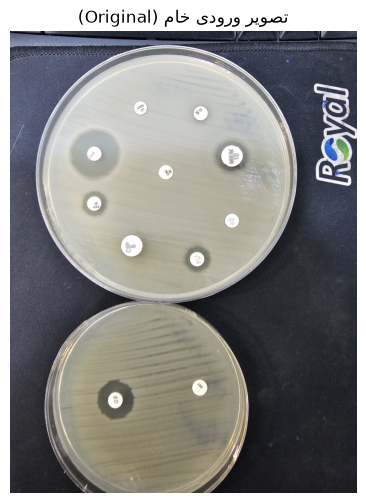

In [5]:
original_bgr = cv2.imread(cfg.image_path, cv2.IMREAD_COLOR)
if original_bgr is None:
    raise FileNotFoundError(f"Could not read image: {cfg.image_path}")

base_gray = cv2.cvtColor(original_bgr, cv2.COLOR_BGR2GRAY)
show(cv2.cvtColor(original_bgr, cv2.COLOR_BGR2RGB), cfg.input_image_title, cfg=cfg)


## ۴) تشخیص ROI ظرف پتری — نسخه status-aware


[Module 4] پتری با روش 'hough_fallback' یافت شد | confidence=0.73 | radius=1109px


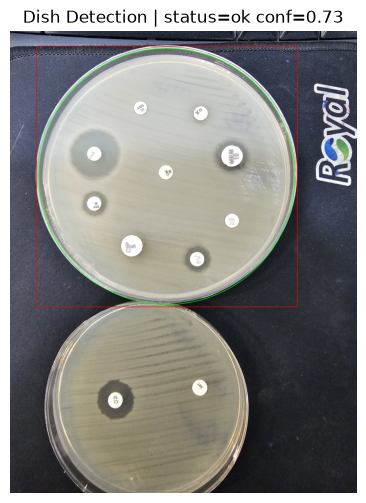

In [6]:
# ── ماژول ۴ — تشخیص خودکار ظرف پتری (Scale-Aware, status-aware) ─────────────
def detect_petri_dish(image_gray: np.ndarray, cfg) -> Dict[str, Any]:
    """
    تشخیص پتری با: نرمال‌سازی، Gaussian، Canny (آستانه از median)،
    Morphological Closing، فیلتر کانتور و در صورت نیاز Hough fallback.
    بازه شعاع نسبت به min(h, w) تعیین می‌شود، نه پیکسل ثابت.
    خروجی: status, confidence, mask, center, radius, method, diagnostics
    """
    fail = {"status": "not_found", "confidence": 0.0, "mask": None,
            "center": None, "radius": None, "method": "none", "diagnostics": {}}

    if image_gray is None or image_gray.size == 0:
        fail["status"] = "error_invalid_input"
        return fail

    h, w = image_gray.shape[:2]
    s_min = float(min(h, w))
    diag_len = float(np.hypot(h, w))
    r_lo = cfg.dish_detect_min_radius_frac * s_min
    r_hi = cfg.dish_detect_max_radius_frac * s_min

    norm = cv2.normalize(image_gray, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)
    k = _safe_odd_ksize(cfg.dish_detect_blur_ksize)
    blur = cv2.GaussianBlur(norm, (k, k), 0)

    med = float(np.median(blur))
    lo_t = int(max(0.0, (1.0 - cfg.dish_detect_canny_sigma) * med))
    hi_t = int(min(255.0, (1.0 + cfg.dish_detect_canny_sigma) * med))
    if hi_t <= lo_t:
        hi_t = lo_t + 1
    edges = cv2.Canny(blur, lo_t, hi_t)

    close_k = _safe_odd_ksize(int(round(cfg.dish_detect_closing_frac * s_min)), minimum=3)
    edges_closed = cv2.morphologyEx(edges, cv2.MORPH_CLOSE, elliptical_kernel(close_k))

    contours, _ = cv2.findContours(edges_closed, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    img_cx, img_cy = w * 0.5, h * 0.5

    def _score_candidate(cx, cy, r, circularity, solidity):
        center_score = 1.0 - min(1.0, float(np.hypot(cx - img_cx, cy - img_cy)) / (0.5 * diag_len))
        border_margin = min(cx, cy, w - cx, h - cy) - r
        border_score = float(np.clip(0.5 + border_margin / (0.10 * s_min), 0.0, 1.0))
        r_mid = 0.5 * (r_lo + r_hi)
        radius_score = 1.0 - min(1.0, abs(r - r_mid) / max(r_hi - r_mid, 1e-6))
        score = (cfg.dish_detect_w_circularity * circularity +
                 cfg.dish_detect_w_solidity * solidity +
                 cfg.dish_detect_w_center * center_score +
                 cfg.dish_detect_w_border * border_score +
                 cfg.dish_detect_w_radius * radius_score)
        return float(np.clip(score, 0.0, 1.0))

    best = None
    for cnt in contours:
        (cx, cy), r = cv2.minEnclosingCircle(cnt)
        if not (r_lo <= r <= r_hi):
            continue
        area = float(cv2.contourArea(cnt))
        if area < np.pi * (r_lo ** 2) * 0.2:
            continue
        peri = max(float(cv2.arcLength(cnt, True)), 1e-6)
        circularity = float(4.0 * np.pi * area / (peri * peri))
        hull = cv2.convexHull(cnt)
        hull_area = max(float(cv2.contourArea(hull)), 1e-6)
        solidity = float(area / hull_area)
        if circularity < cfg.dish_detect_min_circularity:
            continue
        if solidity < cfg.dish_detect_min_solidity:
            continue
        score = _score_candidate(cx, cy, r, circularity, solidity)
        if best is None or score > best["confidence"]:
            best = {"cx": float(cx), "cy": float(cy), "r": float(r),
                    "confidence": score, "method": "contour"}

    if best is None and cfg.dish_detect_use_hough_fallback:
        circles = cv2.HoughCircles(
            blur, cv2.HOUGH_GRADIENT,
            dp=cfg.dish_detect_hough_dp, minDist=s_min,
            param1=cfg.dish_detect_hough_param1, param2=cfg.dish_detect_hough_param2,
            minRadius=int(r_lo), maxRadius=int(r_hi)
        )
        if circles is not None:
            c0 = circles[0][0]
            cx, cy, r = float(c0[0]), float(c0[1]), float(c0[2])
            # circularity/solidity واقعی در Hough در دسترس نیست؛ ضریب احتیاط 0.85
            score = 0.85 * _score_candidate(cx, cy, r, 0.90, 0.90)
            best = {"cx": cx, "cy": cy, "r": r,
                    "confidence": score, "method": "hough_fallback"}

    if best is None:
        fail["diagnostics"] = {"canny_lo": lo_t, "canny_hi": hi_t,
                               "close_k": close_k, "r_lo": r_lo, "r_hi": r_hi}
        return fail

    mask = np.zeros((h, w), dtype=np.uint8)
    cv2.circle(mask, (int(round(best["cx"])), int(round(best["cy"]))),
               int(round(best["r"])), 255, -1)

    return {
        "status": "ok",
        "confidence": float(best["confidence"]),
        "mask": mask,
        "center": (int(round(best["cx"])), int(round(best["cy"]))),
        "radius": float(best["r"]),
        "method": best["method"],
        "diagnostics": {"canny_lo": lo_t, "canny_hi": hi_t,
                        "close_k": close_k, "r_lo": r_lo, "r_hi": r_hi},
    }


petri_result = detect_petri_dish(base_gray, cfg)

if (petri_result["status"] == "ok"
        and petri_result["confidence"] >= cfg.dish_detect_accept_confidence):

    cx_g, cy_g = petri_result["center"]
    r_g = petri_result["radius"]
    pad = cfg.dish_padding_px

    x0 = max(0, int(round(cx_g - r_g)) - pad)
    y0 = max(0, int(round(cy_g - r_g)) - pad)
    x1 = min(base_gray.shape[1], int(round(cx_g + r_g)) + pad)
    y1 = min(base_gray.shape[0], int(round(cy_g + r_g)) + pad)

    dish_bbox = (x0, y0, x1 - x0, y1 - y0)
    roi_gray = base_gray[y0:y1, x0:x1]
    roi_offset_xy = (x0, y0)

    processing_mask_roi = petri_result["mask"][y0:y1, x0:x1].copy()

    if cfg.dish_mask_erode_before_use:
        erode_k = elliptical_kernel(cfg.dish_mask_erode_kernel_size)
        processing_mask_roi = cv2.erode(
            processing_mask_roi, erode_k,
            iterations=cfg.dish_mask_erode_iterations
        )

    roi_gray_masked = _mask_nonzero(roi_gray, processing_mask_roi)

    dish_center_roi_xy = (int(round(cx_g)) - x0, int(round(cy_g)) - y0)
    dish_radius_px = float(r_g)

    dish_roi_result = {
        "status": "ok",
        "confidence": float(petri_result["confidence"]),
        "method": petri_result["method"],
        "used_fallback_full_frame": False,
    }
    print(f"[Module 4] پتری با روش '{petri_result['method']}' یافت شد | "
          f"confidence={petri_result['confidence']:.2f} | radius={dish_radius_px:.0f}px")
else:
    dish_bbox = None
    roi_gray = base_gray
    roi_offset_xy = (0, 0)
    processing_mask_roi = _make_full_mask_like(base_gray)
    roi_gray_masked = base_gray.copy()

    dish_center_roi_xy = (base_gray.shape[1] // 2, base_gray.shape[0] // 2)
    dish_radius_px = 0.5 * float(min(base_gray.shape[:2]))

    dish_roi_result = {
        "status": "fallback_full_frame",
        "confidence": 0.0,
        "method": "none",
        "used_fallback_full_frame": True,
    }
    if cfg.dish_fallback_use_full_frame:
        print(cfg.dish_fallback_message_full_frame)

# قطر پتری بر حسب پیکسل — مرجع مقیاس‌دهی همه‌ی ماژول‌های بعدی
dish_diameter_px = 2.0 * dish_radius_px

vis = original_bgr.copy()
if petri_result["status"] == "ok":
    cv2.circle(vis, petri_result["center"], int(round(petri_result["radius"])), (0, 255, 0), 4)
if dish_bbox is not None:
    bx, by, bw, bh = dish_bbox
    cv2.rectangle(vis, (bx, by), (bx + bw, by + bh), (0, 0, 255), 3)

show(cv2.cvtColor(vis, cv2.COLOR_BGR2RGB),
     f"Dish Detection | status={dish_roi_result['status']} "
     f"conf={dish_roi_result['confidence']:.2f}", cfg=cfg)



## 4.1) ماژول تشخیص دقیق تر پتری

[Module 4.1] ماسک دقیق ساخته شد و فید مرز ظرف با موفقیت روی تصویر ROI اعمال گردید.


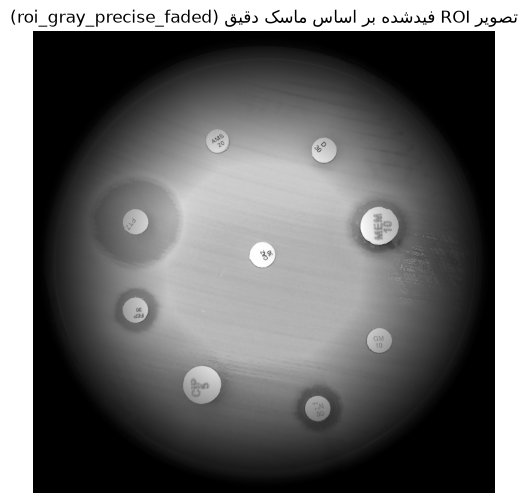

In [7]:
# ── ماژول ۴.۱ — استخراج ماسک دقیق و فید لبه‌های ظرف پتری ───────────────────────────
if roi_gray_masked is None or roi_gray_masked.size == 0:
    raise ValueError("ماژول ۴.۱: roi_gray_masked معتبر نیست یا خالی است.")

if cfg.blur_ksize and cfg.blur_ksize > 1:
    k_precise = _safe_odd_ksize(cfg.blur_ksize)
    img_blur_precise = cv2.GaussianBlur(roi_gray_masked, (k_precise, k_precise), cfg.blur_sigma)
else:
    img_blur_precise = roi_gray_masked.copy()

long_side_p = max(img_blur_precise.shape[:2])
expected_dia_px = (long_side_p / float(cfg.expected_image_long_side_px)) * 60.0
kernel_size_large = _safe_odd_ksize(int(round(cfg.tophat_kernel_scale * expected_dia_px)), minimum=3)
tophat_kernel_l = elliptical_kernel(kernel_size_large)

tophat_l = cv2.morphologyEx(img_blur_precise, cv2.MORPH_TOPHAT, tophat_kernel_l)
tophat_l_masked = _mask_nonzero(tophat_l, processing_mask_roi)

block_l = _safe_odd_ksize(cfg.adaptive_block_size, minimum=3)
thr_l = cv2.adaptiveThreshold(
    tophat_l_masked, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
    cv2.THRESH_BINARY, block_l, int(cfg.adaptive_C)
)
thr_l = cv2.bitwise_and(thr_l, processing_mask_roi)

close_k_large = elliptical_kernel(cfg.morph_closing_ksize_large)
thr_closed_large = cv2.morphologyEx(thr_l, cv2.MORPH_CLOSE, close_k_large)
thr_closed_large = cv2.bitwise_and(thr_closed_large, processing_mask_roi)

open_k_large = elliptical_kernel(cfg.morph_opening_ksize_large)
thr_open_large = cv2.morphologyEx(thr_closed_large, cv2.MORPH_OPEN, open_k_large)
thr_open_large = cv2.bitwise_and(thr_open_large, processing_mask_roi)

precise_dish_mask = _ensure_uint8_binary(thr_open_large)
mask_white_pixels = int(np.count_nonzero(precise_dish_mask))
mask_is_trivial = (mask_white_pixels == 0) or (mask_white_pixels == precise_dish_mask.size)

if not mask_is_trivial:
    roi_gray_precise_faded = apply_border_fade_from_mask(
        roi_gray_masked,
        precise_dish_mask,
        cfg.precise_dish_mask_fade_px
    )
    precise_dish_result = {
        "status": "mask_guided_fade",
        "mask_white_pixels": mask_white_pixels,
        "used_full_image_fallback": False,
    }
    print("[Module 4.1] ماسک دقیق ساخته شد و فید مرز ظرف با موفقیت روی تصویر ROI اعمال گردید.")
else:
    fallback_reason = "empty_mask" if mask_white_pixels == 0 else "full_white_mask"
    if cfg.precise_dish_fallback_to_image_border_fade:
        roi_gray_precise_faded = apply_border_fade(roi_gray_masked, cfg.crop_border_fade_px)
        fallback_mode = "full_roi_border_fade"
    else:
        roi_gray_precise_faded = roi_gray_masked.copy()
        fallback_mode = "no_fade"

    precise_dish_result = {
        "status": f"{fallback_reason}_fallback",
        "mask_white_pixels": mask_white_pixels,
        "used_full_image_fallback": True,
        "fallback_mode": fallback_mode,
    }
    print(f"[Module 4.1 Warning] ماسک ظرف پتری نامعتبر بود ({fallback_reason}). حالت فال‌بک: {fallback_mode}")

show(roi_gray_precise_faded, "تصویر ROI فیدشده بر اساس ماسک دقیق (roi_gray_precise_faded)", cfg=cfg)




## ۵) ماژول: White Top-Hat Transform
جدا کردن دیسک از نور نامنظم پس‌زمینه.

[Module 5] status=ok | kernels: bg=489, tophat=289 | coverage=0.015


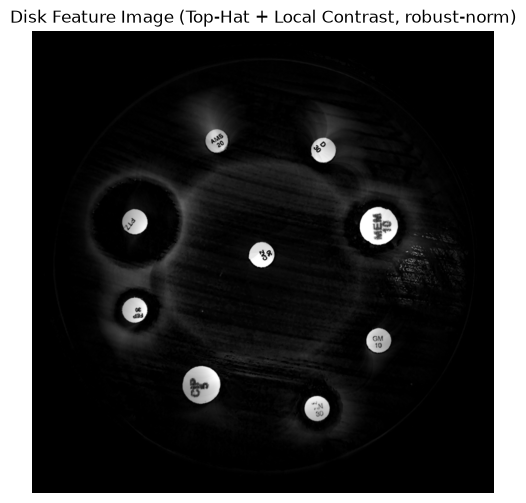

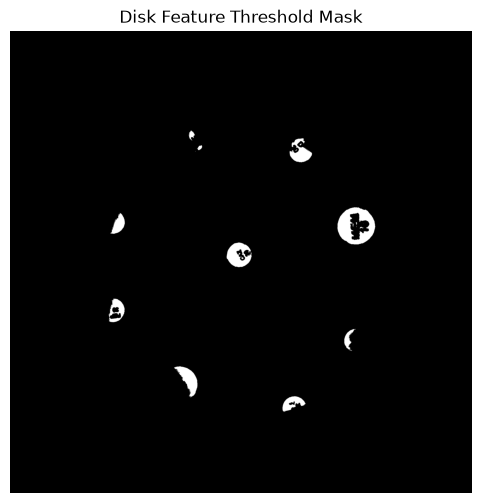

In [8]:
# ── ماژول ۵ — Disk-Specific Feature Image (جایگزین White Top-Hat ساده) ──────
def build_disk_feature_image(gray_roi: np.ndarray,
                             dish_mask: np.ndarray,
                             dish_diameter_px: float,
                             cfg) -> Dict[str, Any]:
    """
    ساخت تصویر ویژه‌ی دیسک سفید:
      ۱) تخمین روشنایی پس‌زمینه با Gaussian بزرگ و Morphological Opening
      ۲) White Top-Hat + کنتراست محلی مثبت
      ۳) ترکیب با نرمال‌سازی robust (percentile-based)
    ابعاد همه‌ی کرنل‌ها از dish_diameter_px و بازه نسبی دیسک مشتق می‌شوند.
    """
    out = {"feature_image": None, "threshold_mask": None,
           "diagnostics": {}, "status": "error_invalid_input"}

    if gray_roi is None or gray_roi.size == 0 or dish_diameter_px <= 0:
        return out

    mask_u8 = _ensure_uint8_binary(dish_mask) if dish_mask is not None \
        else np.full(gray_roi.shape[:2], 255, dtype=np.uint8)

    inside = mask_u8 > 0
    if not np.any(inside):
        out["status"] = "error_empty_mask"
        return out

    disk_d_min = cfg.disk_rel_diameter_min * dish_diameter_px
    disk_d_max = cfg.disk_rel_diameter_max * dish_diameter_px

    blur_k = _safe_odd_ksize(int(round(cfg.disk_feature_blur_frac * disk_d_min)), minimum=3)
    img = cv2.GaussianBlur(gray_roi, (blur_k, blur_k), 0)

    # ۱) پس‌زمینه: Opening برای top-hat و Gaussian بزرگ برای کنتراست محلی
    bg_k = _safe_odd_ksize(int(round(cfg.disk_feature_bg_kernel_scale * disk_d_max)), minimum=3)
    tophat_k = _safe_odd_ksize(int(round(cfg.disk_feature_tophat_kernel_scale * disk_d_max)), minimum=3)

    tophat = cv2.morphologyEx(img, cv2.MORPH_TOPHAT, elliptical_kernel(tophat_k))
    background_gauss = cv2.GaussianBlur(img, (bg_k, bg_k), 0)
    local_contrast = cv2.subtract(img, background_gauss)  # فقط بخش مثبت (uint8 اشباع‌شونده)

    # ۲) نرمال‌سازی robust داخل ماسک پتری
    def _robust01(x: np.ndarray) -> np.ndarray:
        vals = x[inside].astype(np.float32)
        if vals.size == 0:
            return np.zeros(x.shape, dtype=np.float32)
        p_lo, p_hi = np.percentile(vals, [cfg.disk_feature_norm_p_lo,
                                          cfg.disk_feature_norm_p_hi])
        if p_hi <= p_lo:
            return np.zeros(x.shape, dtype=np.float32)
        out01 = np.clip((x.astype(np.float32) - p_lo) / (p_hi - p_lo), 0.0, 1.0)
        out01[~inside] = 0.0
        return out01

    combined = (cfg.disk_feature_w_tophat * _robust01(tophat) +
                cfg.disk_feature_w_contrast * _robust01(local_contrast))
    combined = np.clip(combined / max(cfg.disk_feature_w_tophat +
                                      cfg.disk_feature_w_contrast, 1e-6), 0.0, 1.0)

    feature = (combined * 255.0).astype(np.uint8)
    feature = _mask_nonzero(feature, mask_u8)

    # ۳) ماسک آستانه با percentile داخل پتری
    vals_in = feature[inside]
    thr_val = float(np.percentile(vals_in, cfg.disk_feature_thr_percentile))
    threshold_mask = np.zeros_like(feature)
    threshold_mask[(feature >= max(thr_val, 1.0)) & inside] = 255

    coverage = float(np.count_nonzero(threshold_mask)) / max(int(np.count_nonzero(inside)), 1)
    status = "ok" if coverage <= cfg.disk_feature_max_coverage else "low_contrast"

    out.update({
        "feature_image": feature,
        "threshold_mask": threshold_mask,
        "status": status,
        "diagnostics": {
            "blur_k": blur_k, "bg_k": bg_k, "tophat_k": tophat_k,
            "disk_d_min_px": disk_d_min, "disk_d_max_px": disk_d_max,
            "threshold_value": thr_val, "mask_coverage": coverage,
        },
    })
    return out


if roi_gray_precise_faded is None or roi_gray_precise_faded.size == 0:
    raise ValueError("ماژول ۵: roi_gray_precise_faded معتبر نیست یا خالی است.")

disk_feature_result = build_disk_feature_image(
    roi_gray_precise_faded, processing_mask_roi, dish_diameter_px, cfg
)

if disk_feature_result["feature_image"] is None:
    raise RuntimeError(f"ماژول ۵: ساخت feature ناموفق بود ({disk_feature_result['status']}).")

disk_feature_image = disk_feature_result["feature_image"]
disk_feature_mask = disk_feature_result["threshold_mask"]

# سازگاری با ماژول ۶ (Adaptive Threshold) — قرارداد نام حفظ می‌شود
tophat_masked = disk_feature_image

print(f"[Module 5] status={disk_feature_result['status']} | "
      f"kernels: bg={disk_feature_result['diagnostics']['bg_k']}, "
      f"tophat={disk_feature_result['diagnostics']['tophat_k']} | "
      f"coverage={disk_feature_result['diagnostics']['mask_coverage']:.3f}")

show(disk_feature_image, "Disk Feature Image (Top-Hat + Local Contrast, robust-norm)", cfg=cfg)
show(disk_feature_mask, "Disk Feature Threshold Mask", cfg=cfg)



## ۶) ماژول: Adaptive Threshold
تبدیل تصویر Top-Hat به تصویر باینری با آستانه‌ی محلی.

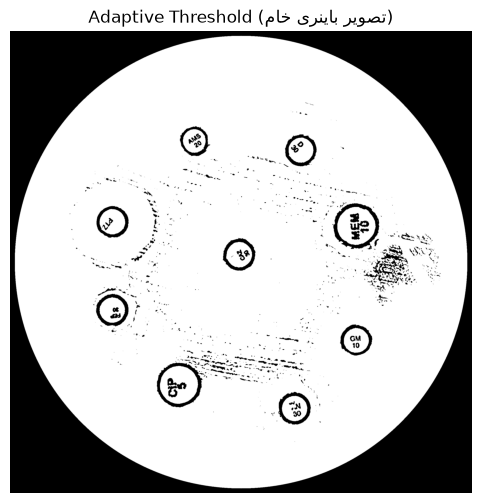

In [9]:
if roi_gray is None or roi_gray.size == 0:
    raise RuntimeError("ماژول ۶: ROI معتبر موجود نیست.")

block = _safe_odd_ksize(cfg.adaptive_block_size, minimum=3)

thr = cv2.adaptiveThreshold(
    tophat_masked,
    255,
    cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
    cv2.THRESH_BINARY,
    block,
    int(cfg.adaptive_C)
)

thr = cv2.bitwise_and(thr, processing_mask_roi)

show(thr, "Adaptive Threshold (تصویر باینری خام)", cfg=cfg)


## ۷) ماژول: Morphological Closing — راه‌حل ۱ (تنها راه‌حل فعال)
پُر کردن حفره‌های ناشی از نوشته‌ی روی دیسک، قبل از Opening.

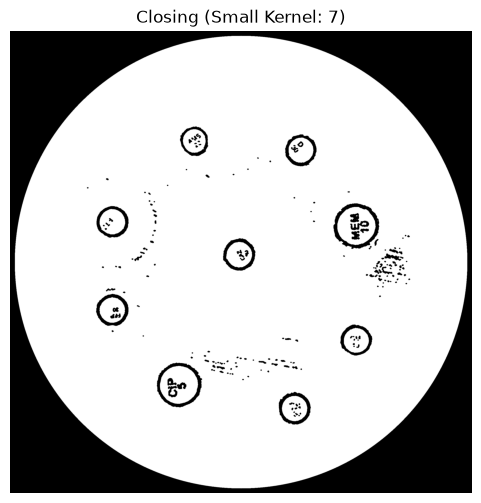

In [10]:
# ── ماژول ۷ — Morphological Closing (شاخه کوچک) ──────────────────────────────
if thr is None or thr.size == 0:
    raise ValueError("ماژول ۷: تصویر باینری ورودی معتبر نیست.")

close_kernel_small = elliptical_kernel(cfg.morph_closing_ksize_small)

# فقط شاخه‌ی سایز کوچک (مربوط به دیسک‌ها) محاسبه می‌شود
thr_closed_small = cv2.morphologyEx(thr, cv2.MORPH_CLOSE, close_kernel_small)
thr_closed_small = cv2.bitwise_and(thr_closed_small, processing_mask_roi)

show(thr_closed_small, f"Closing (Small Kernel: {cfg.morph_closing_ksize_small})", cfg=cfg)


## ۸) ماژول: Morphological Opening
حذف نویزهای ریز باقی‌مانده.

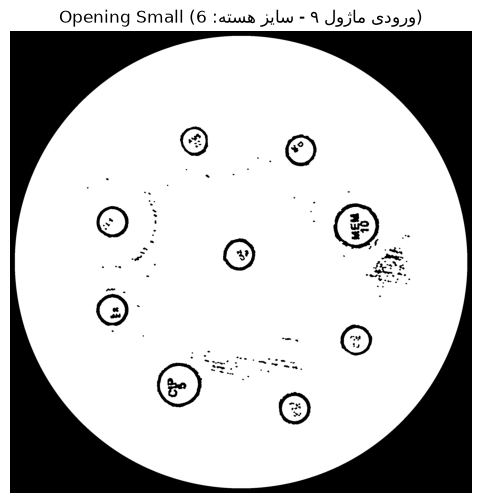

In [11]:
# ── ماژول ۸ — Morphological Opening (شاخه کوچک) ──────────────────────────────
if thr_closed_small is None or thr_closed_small.size == 0:
    raise ValueError("ماژول ۸: thr_closed_small معتبر نیست.")

open_kernel_small = elliptical_kernel(cfg.morph_opening_ksize_small)

# فقط شاخه دیسک‌های کوچک (Opening 5) اجرا می‌شود
thr_open_small = cv2.morphologyEx(thr_closed_small, cv2.MORPH_OPEN, open_kernel_small)
thr_open_small = cv2.bitwise_and(thr_open_small, processing_mask_roi)

show(thr_open_small, f"Opening Small (ورودی ماژول ۹ - سایز هسته: {cfg.morph_opening_ksize_small})", cfg=cfg)


## ۹) ماژول: Distance Transform
هر پیکسل روشن، فاصله‌اش تا نزدیک‌ترین پیکسل تیره (لبه) را نشان می‌دهد.

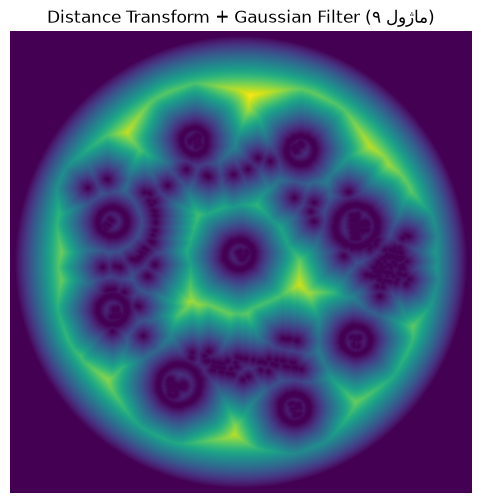

In [12]:
# ── ماژول ۹ — Distance Transform + Gaussian Filtering ───────────────────────
if thr_open_small is None or thr_open_small.size == 0:
    raise ValueError("ماژول ۹: thr_open_small معتبر نیست.")

# محاسبه مستقیم تبدیل فاصله روی شاخه باینری دیسک‌ها
dist = cv2.distanceTransform(
    thr_open_small,
    cv2.DIST_L2,
    3
)

# اعمال ماسک اولیه ظرف پتری
dist = dist * (processing_mask_roi > 0).astype(np.float32)

# اعمال هموارکننده Gaussian
if cfg.dt_gaussian_ksize and cfg.dt_gaussian_ksize > 1:
    dt_gaussian_k = _safe_odd_ksize(cfg.dt_gaussian_ksize)
    dist_filtered = cv2.GaussianBlur(
        dist,
        (dt_gaussian_k, dt_gaussian_k),
        cfg.dt_gaussian_sigma
    )
else:
    dist_filtered = dist.copy()

# تضمین پاک بودن لبه‌های بیرونی
dist_filtered = dist_filtered * (processing_mask_roi > 0).astype(np.float32)

# مقیاس‌دهی جهت نمایش تصویر
dist_norm = cv2.normalize(
    dist_filtered,
    None,
    0,
    255,
    cv2.NORM_MINMAX
).astype(np.uint8)

show(
    dist_norm,
    "Distance Transform + Gaussian Filter (ماژول ۹)",
    cmap="viridis",
    cfg=cfg
)


## ۱۰) ماژول: نقشه‌ی هاله (Halo Gradient Map)
ورودی موردنیاز فیلتر Halo Edge Ratio در ادامه.

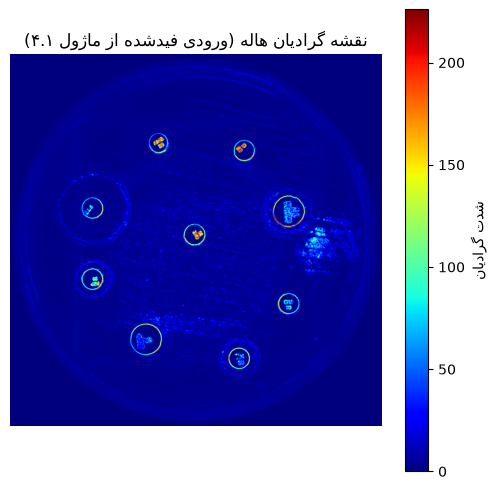

In [13]:
# ── ماژول ۱۰ — نقشه‌ی هاله (Halo Gradient Map) ──────────────────────────────
def preprocess_for_halo(image_gray, cfg):
    blur_k = _safe_odd_ksize(cfg.halo_blur_ksize)
    median_k = _safe_odd_ksize(cfg.halo_median_ksize)

    blur = cv2.GaussianBlur(
        image_gray,
        (blur_k, blur_k),
        cfg.halo_blur_sigma
    )

    clahe = cv2.createCLAHE(
        clipLimit=cfg.halo_clahe_clip_limit,
        tileGridSize=cfg.halo_clahe_tile_grid_size
    ).apply(blur)

    median = cv2.medianBlur(clahe, median_k)

    halo_grad = cv2.morphologyEx(
        median,
        cv2.MORPH_GRADIENT,
        elliptical_kernel(cfg.halo_gradient_kernel_size)
    )

    return halo_grad

if roi_gray_precise_faded is None or roi_gray_precise_faded.size == 0:
    raise ValueError(
        "ماژول ۱۰: خروجی roi_gray_precise_faded از ماژول ۴.۱ معتبر نیست."
    )

# پردازش نقشه هاله‌ی گرادیان روی تصویر فیدشده‌ی نهایی پتری
halo_map = preprocess_for_halo(roi_gray_precise_faded, cfg)
halo_map = _mask_nonzero(halo_map, processing_mask_roi)

plt.figure(figsize=cfg.default_figsize)
plt.imshow(halo_map, cmap="jet")
plt.title("نقشه گرادیان هاله (ورودی فیدشده از ماژول ۴.۱)")
plt.colorbar(label="شدت گرادیان")
plt.axis("off")
plt.show()


## 10.5) Disk- Specific Edge Image

[Module 10.5] status=ok | Canny=(14.3, 35.7) [mad] | density=0.0046


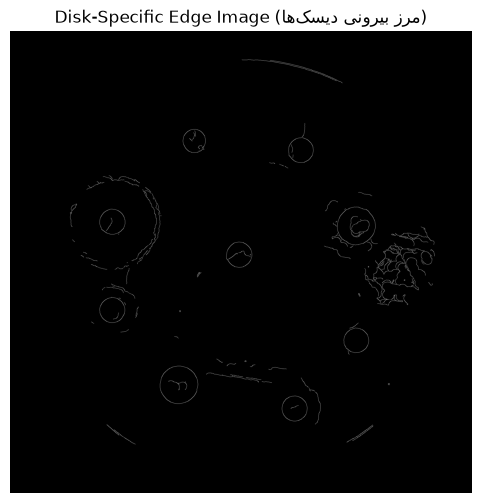

In [14]:
# ── ماژول ۱۰.۵ — Disk-Specific Edge Image ───────────────────────────────────
def build_disk_edge_image(gray_img: np.ndarray,
                          disk_feature_img: np.ndarray,
                          dish_mask: np.ndarray,
                          dish_radius_px: float,
                          cfg) -> Dict[str, Any]:
    """
    تولید edge map مخصوص مرز بیرونی دیسک:
      - حذف مرز پتری با erosion نسبی روی ماسک
      - کنترل ساختارهای داخلی (نوشته‌های سیاه) با closing نسبی
      - آستانه‌های Canny از MAD (با fallback به percentile)، بدون مقدار ثابت
    """
    out = {"edge_image": None, "mask": None, "metrics": {}, "status": "error_invalid_input"}

    if gray_img is None or disk_feature_img is None or disk_feature_img.size == 0:
        return out
    if dish_radius_px <= 0:
        return out

    disk_d_min = cfg.disk_rel_diameter_min * 2.0 * dish_radius_px
    disk_d_max = cfg.disk_rel_diameter_max * 2.0 * dish_radius_px

    # ۱) حذف حاشیه‌ی پتری
    mask_u8 = _ensure_uint8_binary(dish_mask) if dish_mask is not None \
        else np.full(disk_feature_img.shape[:2], 255, dtype=np.uint8)
    margin_k = _safe_odd_ksize(
        int(round(cfg.disk_edge_dish_margin_frac * dish_radius_px)), minimum=3
    )
    inner_mask = cv2.erode(mask_u8, elliptical_kernel(margin_k), iterations=1)

    if np.count_nonzero(inner_mask) == 0:
        out["status"] = "error_empty_inner_mask"
        return out

    feat = _mask_nonzero(disk_feature_img, inner_mask)

    # ۲) پر کردن حفره‌های داخلی دیسک (نوشته‌های سیاه) با closing نسبی
    close_k = _safe_odd_ksize(
        int(round(cfg.disk_edge_text_close_frac * disk_d_min)), minimum=3
    )
    feat_closed = cv2.morphologyEx(feat, cv2.MORPH_CLOSE, elliptical_kernel(close_k))
    feat_closed = cv2.bitwise_and(feat_closed, feat_closed, mask=inner_mask)

    blur_k = _safe_odd_ksize(int(round(cfg.disk_edge_blur_frac * disk_d_min)), minimum=3)
    smooth = cv2.GaussianBlur(feat_closed, (blur_k, blur_k), 0)

    # ۳) آستانه‌های Canny از آماره‌های robust تصویر (MAD یا percentile)
    vals = smooth[inner_mask > 0].astype(np.float32)
    med = float(np.median(vals))
    mad = float(np.median(np.abs(vals - med)))
    if mad > 1e-6:
        hi_t = float(np.clip(med + cfg.disk_edge_mad_k_high * 1.4826 * mad, 10.0, 255.0))
        thr_method = "mad"
    else:
        hi_t = float(np.clip(np.percentile(vals, 90.0), 10.0, 255.0))
        thr_method = "percentile_fallback"
    lo_t = cfg.disk_edge_low_ratio * hi_t

    edges = cv2.Canny(smooth, lo_t, hi_t)
    edges = cv2.bitwise_and(edges, inner_mask)

    inside_area = max(int(np.count_nonzero(inner_mask)), 1)
    edge_density = float(np.count_nonzero(edges)) / float(inside_area)

    if edge_density < cfg.disk_edge_min_density:
        status = "weak_edges"
    elif edge_density > cfg.disk_edge_max_density:
        status = "noisy_edges"
    else:
        status = "ok"

    out.update({
        "edge_image": edges,
        "mask": inner_mask,
        "status": status,
        "metrics": {
            "canny_low": lo_t, "canny_high": hi_t, "thr_method": thr_method,
            "edge_density": edge_density,
            "margin_k": margin_k, "close_k": close_k, "blur_k": blur_k,
        },
    })
    return out


disk_edge_result = build_disk_edge_image(
    roi_gray_precise_faded, disk_feature_image,
    processing_mask_roi, dish_radius_px, cfg
)

if disk_edge_result["edge_image"] is None:
    raise RuntimeError(f"ماژول ۱۰.۵: ساخت edge ناموفق بود ({disk_edge_result['status']}).")

disk_edge_image = disk_edge_result["edge_image"]
disk_edge_inner_mask = disk_edge_result["mask"]

m = disk_edge_result["metrics"]
print(f"[Module 10.5] status={disk_edge_result['status']} | "
      f"Canny=({m['canny_low']:.1f}, {m['canny_high']:.1f}) [{m['thr_method']}] | "
      f"density={m['edge_density']:.4f}")

show(disk_edge_image, "Disk-Specific Edge Image (مرز بیرونی دیسک‌ها)", cfg=cfg)


## ۱۱) ماژول Hough ROI-aware
این فیلتر از halo_map (خروجی ماژول ۱۰) و ماسک محدوده کننده (thr_open_large) استفاده می‌کند. در صورتی که ماسک فاقد پیکسل سفید باشد، به صورت خودکار به کل تصویر سوئیچ می‌کند.

Hough (Scale-Aware): 9 کاندید معتبر یافت شد.


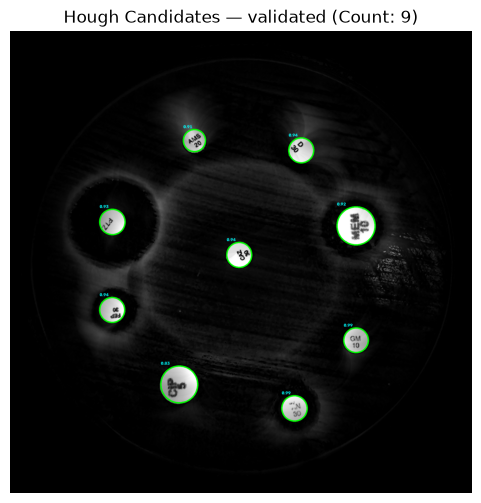

In [17]:
# ── ماژول ۱۱ — Hough Circle دیسک (Scale-Aware + Validation) ─────────────────
def run_disk_hough(feature_img: np.ndarray,
                   edge_img: Optional[np.ndarray],
                   dish_mask: np.ndarray,
                   dish_center_xy: Tuple[int, int],
                   dish_radius_px: float,
                   cfg) -> List[Dict[str, Any]]:
    """
    HoughCircles روی disk feature image (نه تصویر خام) با اعتبارسنجی:
      - containment داخل پتری
      - edge support از disk-specific edge image
      - اختلاف شدت داخل دیسک نسبت به حلقه اطراف
      - بازه شعاع نسبی (مشتق از dish_radius_px)
    """
    result: List[Dict[str, Any]] = []
    if feature_img is None or feature_img.size == 0 or dish_radius_px <= 0:
        return result

    dish_diameter = 2.0 * float(dish_radius_px)
    d_min = cfg.disk_rel_diameter_min * dish_diameter
    d_max = cfg.disk_rel_diameter_max * dish_diameter
    m = cfg.disk_hough_radius_margin

    min_r = max(3, int(round(0.5 * d_min * (1.0 - m))))
    max_r = max(min_r + 1, int(round(0.5 * d_max * (1.0 + m))))
    min_dist = max(1, int(round(cfg.disk_hough_min_dist_scale * d_min)))

    blur_k = _safe_odd_ksize(int(round(cfg.disk_feature_blur_frac * d_min)), minimum=3)
    search_img = cv2.GaussianBlur(feature_img, (blur_k, blur_k), 0)

    circles = cv2.HoughCircles(
        search_img, cv2.HOUGH_GRADIENT,
        dp=cfg.disk_hough_dp, minDist=min_dist,
        param1=cfg.disk_hough_param1, param2=cfg.disk_hough_param2,
        minRadius=min_r, maxRadius=max_r
    )
    if circles is None:
        return result

    h, w = feature_img.shape[:2]
    edge_band = None
    if edge_img is not None and edge_img.size > 0:
        edge_band = cv2.dilate(edge_img, np.ones((3, 3), np.uint8))

    dcx, dcy = float(dish_center_xy[0]), float(dish_center_xy[1])
    angles = np.linspace(0.0, 2.0 * np.pi,
                         cfg.disk_hough_num_angle_samples, endpoint=False)
    cos_a, sin_a = np.cos(angles), np.sin(angles)
    r_lo, r_hi = 0.5 * d_min, 0.5 * d_max

    for c in circles[0]:
        x, y, r = float(c[0]), float(c[1]), float(c[2])
        xi, yi, ri = int(round(x)), int(round(y)), int(round(r))

        # ۱) containment داخل پتری
        if np.hypot(x - dcx, y - dcy) + r > cfg.disk_hough_containment_frac * dish_radius_px:
            continue
        if not candidate_allowed_by_mask(dish_mask, xi, yi, ri, cfg):
            continue

        # ۲) edge support روی محیط دایره
        edge_support = 0.0
        if edge_band is not None:
            px = np.clip(np.round(x + r * cos_a).astype(int), 0, w - 1)
            py = np.clip(np.round(y + r * sin_a).astype(int), 0, h - 1)
            edge_support = float(np.count_nonzero(edge_band[py, px])) / float(len(angles))

        # ۳) شدت داخل دیسک نسبت به حلقه اطراف (روی feature image)
        inner_mean = _sample_disk_mean(feature_img, xi, yi, max(2, int(round(0.8 * r))))
        ring_mean = _sample_ring_mean(feature_img, xi, yi, ri, 1.15, 1.50)
        intensity_score = float(np.clip((inner_mean - ring_mean) /
                                        cfg.disk_hough_intensity_ref, 0.0, 1.0))

        # ۴) امتیاز بازه شعاع نسبی
        if r_lo <= r <= r_hi:
            radius_score = 1.0
        else:
            band = max(m * 0.5 * d_max, 1.0)
            radius_score = float(np.clip(
                1.0 - max(r_lo - r, r - r_hi) / band, 0.0, 1.0))

        confidence = 0.40 * edge_support + 0.35 * intensity_score + 0.25 * radius_score

        if edge_support < cfg.disk_hough_min_edge_support:
            continue
        if confidence < cfg.disk_hough_min_confidence:
            continue

        result.append({
            "x": xi, "y": yi, "r": ri,
            "type": "hough", "source": "hough",
            "confidence": float(confidence),
            "edge_support": float(edge_support),
            "intensity_score": intensity_score,
            "radius_score": radius_score,
        })

    result.sort(key=lambda c: (-c["confidence"], c["x"], c["y"], c["r"]))
    return result


hough_candidates = run_disk_hough(
    disk_feature_image, disk_edge_image,
    processing_mask_roi, dish_center_roi_xy, dish_radius_px, cfg
)
print(f"Hough (Scale-Aware): {len(hough_candidates)} کاندید معتبر یافت شد.")

vis_hough = cv2.cvtColor(disk_feature_image, cv2.COLOR_GRAY2BGR)
for c in hough_candidates:
    cv2.circle(vis_hough, (c["x"], c["y"]), c["r"], (0, 255, 0), 5)
    cv2.putText(vis_hough, f"{c['confidence']:.2f}",
                (c["x"] - c["r"], c["y"] - c["r"] - 6),
                cv2.FONT_HERSHEY_SIMPLEX, 0.7, (0, 255, 255), 2, cv2.LINE_AA)
show(vis_hough, f"Hough Candidates — validated (Count: {len(hough_candidates)})", cfg=cfg)


## ۱۲) ماژول جدید تحلیل Blob Analysis
این سلول ویژگی‌های اتصال تصویر باینریِ شاخه‌ی کوچک (thr_open_small) را تحلیل کرده و با سنجه‌های هندسی پالایش می‌کند.

Blob Analysis: 2 کاندید یافت شد.


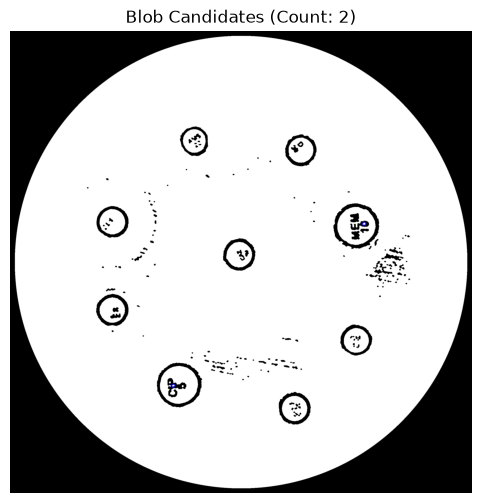

In [19]:
# ── ماژول ۱۲ — تحلیل Blob Analysis ──────────────────────────────────────────
def run_blob_analysis(thr_open_small, dist_map, processing_mask, cfg):
    num_labels, labels, stats, centroids = cv2.connectedComponentsWithStats(
        thr_open_small
    )

    blob_candidates = []

    for i in range(1, num_labels):
        area = stats[i, cv2.CC_STAT_AREA]

        # ۱) فیلتر مساحت بلاب
        if not (cfg.blob_min_area <= area <= cfg.blob_max_area):
            continue

        cx, cy = centroids[i]
        cx, cy = int(round(cx)), int(round(cy))

        if not _candidate_center_inside_mask(processing_mask, cx, cy):
            continue

        component_mask = (labels == i).astype(np.uint8) * 255

        contours, _ = cv2.findContours(
            component_mask,
            cv2.RETR_EXTERNAL,
            cv2.CHAIN_APPROX_SIMPLE
        )

        if not contours:
            continue

        cnt = contours[0]
        cnt_area = max(cv2.contourArea(cnt), 1e-6)
        peri = max(cv2.arcLength(cnt, True), 1e-6)

        # ۲) Circularity
        circularity = float(4.0 * np.pi * cnt_area / (peri * peri))

        if not (
            cfg.blob_min_circularity
            <= circularity
            <= cfg.blob_max_circularity
        ):
            continue

        # ۳) Solidity
        hull = cv2.convexHull(cnt)
        hull_area = max(cv2.contourArea(hull), 1e-6)
        solidity = float(cnt_area / hull_area)

        if not (
            cfg.blob_min_solidity
            <= solidity
            <= cfg.blob_max_solidity
        ):
            continue

        # ۴) شعاع از DT Gaussian-filtered
        dt_patch = dist_map * (labels == i)
        _, max_val, _, max_loc = cv2.minMaxLoc(dt_patch)

        r_estimated = int(round(max_val))

        if r_estimated < cfg.hough_min_r or r_estimated > cfg.hough_max_r:
            r_estimated = int(round(
                (
                    stats[i, cv2.CC_STAT_WIDTH]
                    + stats[i, cv2.CC_STAT_HEIGHT]
                ) / 4.0
            ))

        # ۵) Fill Ratio
        bbox_w = stats[i, cv2.CC_STAT_WIDTH]
        bbox_h = stats[i, cv2.CC_STAT_HEIGHT]

        fill_ratio = cnt_area / max(float(bbox_w * bbox_h), 1e-6)

        if not (
            cfg.blob_min_fill_ratio
            <= fill_ratio
            <= cfg.blob_max_fill_ratio
        ):
            continue

        blob_candidates.append({
            "x": cx,
            "y": cy,
            "r": r_estimated,
            "area": area,
            "circularity": circularity,
            "solidity": solidity,
            "fill_ratio": fill_ratio,
            "type": "blob"
        })

    return blob_candidates


# ورودی DT اکنون خروجی Gaussian‌شده‌ی ماژول ۹ است.
blob_candidates = run_blob_analysis(
    thr_open_small,
    dist_filtered,
    processing_mask_roi,
    cfg
)

print(f"Blob Analysis: {len(blob_candidates)} کاندید یافت شد.")

vis_blob = cv2.cvtColor(thr_open_small, cv2.COLOR_GRAY2BGR)

for b in blob_candidates:
    cv2.circle(
        vis_blob,
        (b["x"], b["y"]),
        b["r"],
        (0, 0, 255),
        4
    )

show(
    vis_blob,
    f"Blob Candidates (Count: {len(blob_candidates)})",
    cfg=cfg
)


## ۱۳) شاخه سوم: کاندیدهای DT

Distance Transform Peaks: 61 کاندید یافت شد.


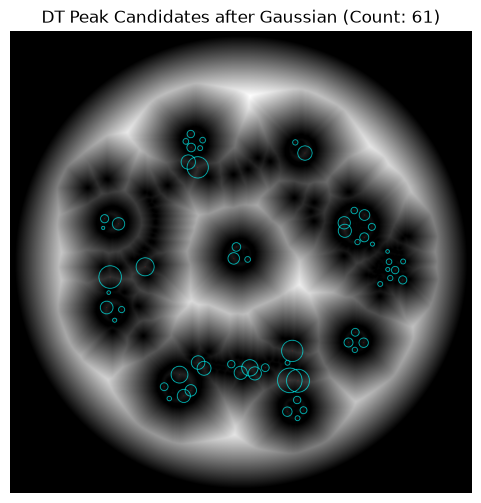

In [22]:
# ── ماژول ۱۳ — کاندیدهای مبتنی بر DT Peaks ──────────────────────────────────
# قله‌ها از خروجی Gaussian-filtered ماژول ۹ استخراج می‌شوند.

xs_dt, ys_dt, vals_dt = _local_maxima(
    dist_filtered.astype(np.float32),
    cfg.dt_peak_window,
    cfg.dt_peak_min_value,
    processing_mask_roi
)

raw_rs_dt = np.round(
    vals_dt * float(cfg.dt_radius_scale)
).astype(int)

valid_dt = (
    (raw_rs_dt >= int(cfg.candidate_r_min))
    &
    (raw_rs_dt <= int(cfg.candidate_r_max))
)

xs_dt = xs_dt[valid_dt]
ys_dt = ys_dt[valid_dt]
rs_dt = raw_rs_dt[valid_dt]
scores_dt = vals_dt[valid_dt]

dt_candidates = []

for idx_dt in range(len(xs_dt)):
    dt_candidates.append({
        "x": int(xs_dt[idx_dt]),
        "y": int(ys_dt[idx_dt]),
        "r": int(rs_dt[idx_dt]),
        "score_peak": float(scores_dt[idx_dt]),
        "type": "dt"
    })

print(f"Distance Transform Peaks: {len(dt_candidates)} کاندید یافت شد.")

vis_dt = cv2.cvtColor(dist_norm, cv2.COLOR_GRAY2BGR)

for c in dt_candidates:
    cv2.circle(
        vis_dt,
        (c["x"], c["y"]),
        max(2, c["r"]),
        (0, 255, 255),
        2
    )

    cv2.circle(
        vis_dt,
        (c["x"], c["y"]),
        1,
        (255, 0, 0),
        -1
    )

show(
    vis_dt,
    f"DT Peak Candidates after Gaussian (Count: {len(dt_candidates)})",
    cfg=cfg
)


## ۱۴) ماژول جدید ادغام و امتیازدهی تلفیقی (Fusion Score) + NMS نهایی
در این مرحله، تمام کاندیدها از سه شاخه مجزا جمع‌آوری شده و هرکدام بر اساس میزان تطابق با ویژگی‌های شاخه‌های دیگر امتیازدهی می‌شوند و در نهایت NMS اعمال می‌شود.

In [23]:
# ── ماژول ۱۴ — Fusion سه‌شاخه (Hough + DT + Blob) با NMS هندسی ──────────────
# طراحی deterministic (مرتب‌سازی پایدار + tie-break صریح) و قابل انتقال به ++C
# (فقط حلقه، جمع/ضرب و فرمول بسته‌ی هم‌پوشانی دو دایره).

def _circle_overlap_ratio(x1, y1, r1, x2, y2, r2) -> float:
    """نسبت مساحت اشتراک دو دایره به مساحت دایره‌ی کوچک‌تر (فرم بسته)."""
    if r1 <= 0 or r2 <= 0:
        return 0.0
    d = float(np.hypot(x1 - x2, y1 - y2))
    if d >= r1 + r2:
        return 0.0
    rs = min(r1, r2)
    if d <= abs(r1 - r2):
        return 1.0
    a1 = r1 * r1 * np.arccos(np.clip((d * d + r1 * r1 - r2 * r2) / (2 * d * r1), -1.0, 1.0))
    a2 = r2 * r2 * np.arccos(np.clip((d * d + r2 * r2 - r1 * r1) / (2 * d * r2), -1.0, 1.0))
    a3 = 0.5 * np.sqrt(max(0.0, (-d + r1 + r2) * (d + r1 - r2) * (d - r1 + r2) * (d + r1 + r2)))
    inter = a1 + a2 - a3
    return float(np.clip(inter / (np.pi * rs * rs), 0.0, 1.0))


def _normalize_branch_candidates(cands, branch, r_max_px):
    out = []
    for c in cands:
        conf = c.get("confidence")
        if conf is None:
            if branch == "dt":
                conf = float(np.clip(c.get("score_peak", 0.0) / max(r_max_px, 1e-6), 0.0, 1.0))
            elif branch == "blob":
                conf = float(np.clip(0.5 * (c.get("circularity", 0.0) +
                                            c.get("solidity", 0.0)), 0.0, 1.0))
            else:
                conf = 0.5
        out.append({"x": float(c["x"]), "y": float(c["y"]), "r": float(c["r"]),
                    "branch": branch, "conf": float(conf)})
    out.sort(key=lambda c: (-c["conf"], c["x"], c["y"], c["r"]))
    return out


def _branch_quality(norm_cands, r_min_px, r_max_px, expected_max_count) -> float:
    """کیفیت شاخه از: سهم کاندیدهای داخل بازه شعاع نسبی، میانگین confidence و معقول‌بودن تعداد."""
    if not norm_cands:
        return 0.0
    n = len(norm_cands)
    in_range = float(np.mean([1.0 if r_min_px <= c["r"] <= r_max_px else 0.0
                              for c in norm_cands]))
    mean_conf = float(np.mean([c["conf"] for c in norm_cands]))
    count_factor = 1.0 if n <= expected_max_count else max(0.2, expected_max_count / float(n))
    return float(np.clip((0.5 * in_range + 0.5 * mean_conf) * count_factor, 0.0, 1.0))


def fuse_disk_candidates(hough_cands, dt_cands, blob_cands, dish_diameter_px, cfg):
    r_min_px = 0.5 * cfg.disk_rel_diameter_min * dish_diameter_px
    r_max_px = 0.5 * cfg.disk_rel_diameter_max * dish_diameter_px

    branches = {
        "hough": _normalize_branch_candidates(hough_cands, "hough", r_max_px),
        "dt":    _normalize_branch_candidates(dt_cands, "dt", r_max_px),
        "blob":  _normalize_branch_candidates(blob_cands, "blob", r_max_px),
    }
    base_w = {"hough": cfg.fusion_w_hough, "dt": cfg.fusion_w_dt, "blob": cfg.fusion_w_blob}
    quality = {b: _branch_quality(branches[b], r_min_px, r_max_px,
                                  cfg.fusion_expected_max_count) for b in branches}
    # وزن adaptive: وزن پایه × کیفیت شاخه (کف 0.05 برای شاخه‌های حاضر ولی ضعیف)
    adaptive_w = {b: base_w[b] * max(quality[b], 0.05) for b in branches}

    branch_order = {"hough": 0, "dt": 1, "blob": 2}
    all_norm = branches["hough"] + branches["dt"] + branches["blob"]
    all_norm.sort(key=lambda c: (-c["conf"], branch_order[c["branch"]],
                                 c["x"], c["y"], c["r"]))

    # خوشه‌بندی greedy با فاصله نرمال‌شده و هم‌پوشانی دایره‌ها
    clusters = []
    for c in all_norm:
        target = None
        for cl in clusters:
            d = float(np.hypot(c["x"] - cl["x"], c["y"] - cl["y"]))
            norm_d = d / max(cl["r"], c["r"], 1e-6)
            ov = _circle_overlap_ratio(c["x"], c["y"], c["r"], cl["x"], cl["y"], cl["r"])
            if norm_d < cfg.fusion_merge_norm_dist or ov > cfg.fusion_merge_overlap:
                target = cl
                break
        if target is None:
            clusters.append({"x": c["x"], "y": c["y"], "r": c["r"], "members": [c]})
        else:
            target["members"].append(c)
            ws = np.array([adaptive_w[m["branch"]] * m["conf"] + 1e-6
                           for m in target["members"]], dtype=np.float64)
            target["x"] = float(np.sum(ws * [m["x"] for m in target["members"]]) / np.sum(ws))
            target["y"] = float(np.sum(ws * [m["y"] for m in target["members"]]) / np.sum(ws))
            target["r"] = float(np.sum(ws * [m["r"] for m in target["members"]]) / np.sum(ws))

    w_total = max(sum(adaptive_w.values()), 1e-6)
    fused = []
    for cl in clusters:
        support = {b: 0.0 for b in branches}
        for mmb in cl["members"]:
            support[mmb["branch"]] = max(support[mmb["branch"]], mmb["conf"])
        branch_score = sum(adaptive_w[b] * support[b] for b in branches) / w_total
        fused.append({
            "x": int(round(cl["x"])), "y": int(round(cl["y"])), "r": int(round(cl["r"])),
            "sources": sorted({mmb["branch"] for mmb in cl["members"]}),
            "hough_support": float(support["hough"]),
            "dt_support": float(support["dt"]),
            "blob_support": float(support["blob"]),
            "branch_score": float(branch_score),
        })

    fused.sort(key=lambda c: (-c["branch_score"], c["x"], c["y"], c["r"]))
    return fused, quality, adaptive_w, (r_min_px, r_max_px)


fused_candidates, fusion_branch_quality, fusion_adaptive_w, (fusion_r_min, fusion_r_max) = \
    fuse_disk_candidates(hough_candidates, dt_candidates, blob_candidates,
                         dish_diameter_px, cfg)

print(f"[Fusion] کیفیت شاخه‌ها: "
      f"Hough={fusion_branch_quality['hough']:.2f} "
      f"DT={fusion_branch_quality['dt']:.2f} "
      f"Blob={fusion_branch_quality['blob']:.2f} | "
      f"بازه شعاع مجاز: [{fusion_r_min:.0f}, {fusion_r_max:.0f}] px")

# اعتبارسنجی هندسی، امتیاز نهایی و rejection reasons برای هر کاندید
rm = cfg.disk_hough_radius_margin
fusion_report = []
for c in fused_candidates:
    reasons = []

    if not (fusion_r_min * (1.0 - rm) <= c["r"] <= fusion_r_max * (1.0 + rm)):
        reasons.append("radius_out_of_range")
    if not candidate_allowed_by_mask(processing_mask_roi, c["x"], c["y"], c["r"], cfg):
        reasons.append("outside_dish")

    geom = None
    if not reasons:
        pad = int(max(6, round(c["r"] * 0.4)))
        x0 = max(0, c["x"] - c["r"] - pad)
        y0 = max(0, c["y"] - c["r"] - pad)
        x1 = min(thr_open_small.shape[1], c["x"] + c["r"] + pad)
        y1 = min(thr_open_small.shape[0], c["y"] + c["r"] + pad)
        geom = geom_metrics_for_circle(
            thr_open_small[y0:y1, x0:x1],
            processing_mask_roi[y0:y1, x0:x1],
            c["x"] - x0, c["y"] - y0, c["r"]
        )
        if geom is None:
            reasons.append("no_geometry")

    entry = dict(c)
    entry.update(geom if geom else
                 {"circularity": 0.0, "solidity": 0.0, "fill_ratio": 0.0})

    if geom is not None:
        if entry["circularity"] < cfg.min_circularity:
            reasons.append("low_circularity")
        if entry["solidity"] < cfg.min_solidity:
            reasons.append("low_solidity")

    geo_score = (0.5 * entry["circularity"] +
                 0.3 * entry["solidity"] +
                 0.2 * entry["fill_ratio"])
    entry["score"] = float(cfg.fusion_branch_score_weight * c["branch_score"] +
                           (1.0 - cfg.fusion_branch_score_weight) * geo_score)

    if entry["score"] < cfg.fusion_min_score:
        reasons.append("low_score")

    entry["rejection_reasons"] = reasons
    entry["status"] = "accepted" if not reasons else "rejected"
    fusion_report.append(entry)

# NMS نهایی روی پذیرفته‌شده‌ها (فاصله نرمال‌شده + هم‌پوشانی مساحتی)
accepted = [c for c in fusion_report if c["status"] == "accepted"]
accepted.sort(key=lambda c: (-c["score"], c["x"], c["y"], c["r"]))

final_candidates = []
for c in accepted:
    keep = True
    for k in final_candidates:
        d = float(np.hypot(c["x"] - k["x"], c["y"] - k["y"]))
        ov = _circle_overlap_ratio(c["x"], c["y"], c["r"], k["x"], k["y"], k["r"])
        if d < cfg.fusion_nms_center_frac * (c["r"] + k["r"]) or ov > cfg.fusion_nms_overlap:
            keep = False
            break
    if keep:
        final_candidates.append(c)

rejected = [c for c in fusion_report if c["status"] == "rejected"]
reason_counts: Dict[str, int] = {}
for c in rejected:
    for rr in c["rejection_reasons"]:
        reason_counts[rr] = reason_counts.get(rr, 0) + 1

print(f"پس از Fusion و NMS نهایی: {len(final_candidates)} دیسک پذیرفته شد | "
      f"{len(rejected)} کاندید رد شد.")
if reason_counts:
    print("دلایل رد:", ", ".join(f"{k}={v}" for k, v in sorted(reason_counts.items())))


[Fusion] کیفیت شاخه‌ها: Hough=0.97 DT=0.04 Blob=0.37 | بازه شعاع مجاز: [44, 111] px
پس از Fusion و NMS نهایی: 15 دیسک پذیرفته شد | 18 کاندید رد شد.
دلایل رد: low_score=18, radius_out_of_range=18


## ۱۵) سلول رسم نتایج نهایی 
این بخش نتایج نهایی حاصل از الگوریتم ادغام و ساختار جدید را به همراه متادیتا نمایش می‌دهد.

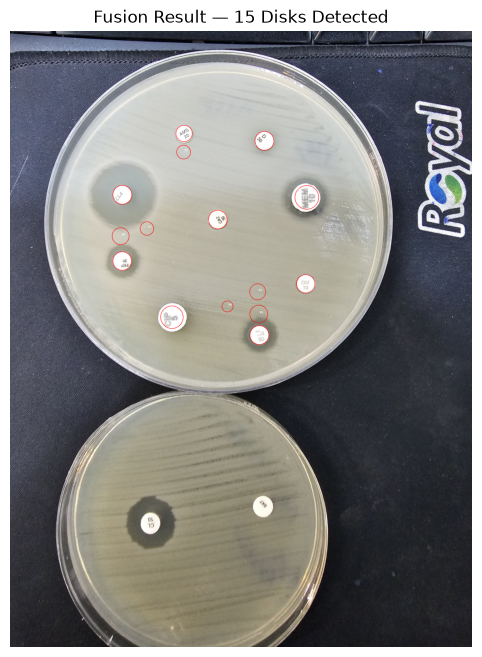

دیسک 1: مرکز=(1927,1080)  شعاع=77px  Score=0.88 | Sources=3 [blob+dt+hough] | Support[H=0.92 DT=0.29 Blob=0.75] | circ=0.89 solid=0.99
دیسک 2: مرکز=(1051,1858)  شعاع=73px  Score=0.84 | Sources=3 [blob+dt+hough] | Support[H=0.83 DT=0.37 Blob=0.74] | circ=0.89 solid=0.99
دیسک 3: مرکز=(1619,1974)  شعاع=61px  Score=0.84 | Sources=2 [dt+hough] | Support[H=0.99 DT=0.20 Blob=0.00] | circ=0.89 solid=0.99
دیسک 4: مرکز=(1920,1641)  شعاع=59px  Score=0.83 | Sources=2 [dt+hough] | Support[H=0.99 DT=0.21 Blob=0.00] | circ=0.89 solid=0.99
دیسک 5: مرکز=(1652,713)  شعاع=61px  Score=0.81 | Sources=2 [dt+hough] | Support[H=0.94 DT=0.31 Blob=0.00] | circ=0.89 solid=0.99
دیسک 6: مرکز=(1349,1224)  شعاع=60px  Score=0.81 | Sources=2 [dt+hough] | Support[H=0.94 DT=0.25 Blob=0.00] | circ=0.89 solid=0.99
دیسک 7: مرکز=(728,1493)  شعاع=60px  Score=0.81 | Sources=2 [dt+hough] | Support[H=0.94 DT=0.28 Blob=0.00] | circ=0.89 solid=0.99
دیسک 8: مرکز=(729,1063)  شعاع=61px  Score=0.81 | Sources=2 [dt+hough] | Support[H=

In [24]:
# ── نمایش نتایج نهایی ───────────────────────────────────────────────────────
final_overlay = original_bgr.copy()
offset_x, offset_y = roi_offset_xy if roi_offset_xy is not None else (0, 0)

for idx, c in enumerate(final_candidates, start=1):
    gx, gy = c["x"] + offset_x, c["y"] + offset_y
    cv2.circle(final_overlay, (gx, gy), c["r"], (0, 0, 255), 2)
    cv2.putText(
        final_overlay,
        str(idx),
        (gx + 6, gy - 6),
        cv2.FONT_HERSHEY_SIMPLEX,
        0.6,
        (255, 255, 255),
        2,
        cv2.LINE_AA
    )

show(
    cv2.cvtColor(final_overlay, cv2.COLOR_BGR2RGB),
    f"Fusion Result — {len(final_candidates)} Disks Detected",
    figsize=cfg.final_figsize,
    cfg=cfg
)

for idx, c in enumerate(final_candidates, start=1):
    # پشتیبانی شاخه‌ها با نام‌گذاری صحیح ماژول Fusion (support-based)
    votes_str = (
        f"H={c.get('hough_support', 0.0):.2f} "
        f"DT={c.get('dt_support', 0.0):.2f} "
        f"Blob={c.get('blob_support', 0.0):.2f}"
    )
    sources = c.get("sources", [])
    num_sources = len(sources)
    sources_str = "+".join(sources) if sources else "-"

    print(
        f"دیسک {idx}: مرکز=({c['x'] + offset_x},{c['y'] + offset_y})  شعاع={c['r']}px  "
        f"Score={c.get('score', 0.0):.2f} | Sources={num_sources} [{sources_str}] "
        f"| Support[{votes_str}] "
        f"| circ={c.get('circularity', 0.0):.2f} solid={c.get('solidity', 0.0):.2f}"
    )


## ۱۶)  تشخیص هاله‌ی مهار 

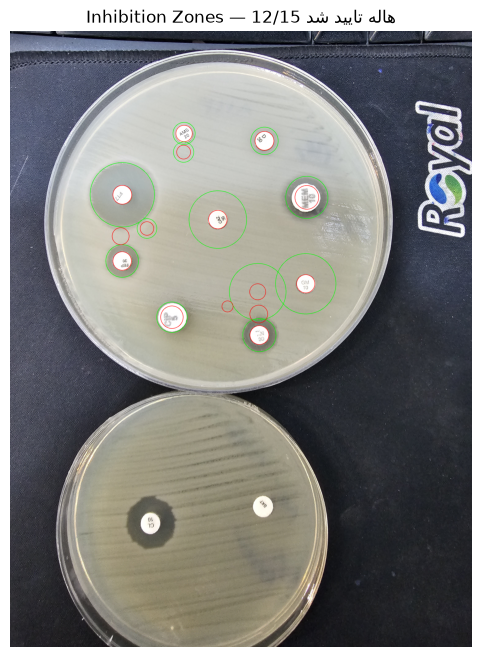

دیسک 1: status=ok | conf=1.00 | contrast=-10.6σ | continuity=0.99 | r_halo=136.5px | قطر ناحیه مهار ≈ 11.1 mm
دیسک 2: status=ok | conf=0.89 | contrast=+7.0σ | continuity=0.68 | r_halo=99.2px | قطر ناحیه مهار ≈ 8.0 mm
دیسک 3: status=ok | conf=1.00 | contrast=-39.3σ | continuity=1.00 | r_halo=108.2px | قطر ناحیه مهار ≈ 8.8 mm
دیسک 4: status=ok | conf=0.52 | contrast=-3.3σ | continuity=0.47 | r_halo=196.3px | قطر ناحیه مهار ≈ 15.9 mm
دیسک 5: status=ok | conf=0.89 | contrast=-10.0σ | continuity=0.96 | r_halo=89.2px | قطر ناحیه مهار ≈ 7.2 mm
دیسک 6: status=ok | conf=0.41 | contrast=-2.0σ | continuity=0.53 | r_halo=187.2px | قطر ناحیه مهار ≈ 15.2 mm
دیسک 7: status=ok | conf=0.92 | contrast=-7.0σ | continuity=1.00 | r_halo=106.4px | قطر ناحیه مهار ≈ 8.6 mm
دیسک 8: status=ok | conf=0.99 | contrast=-23.5σ | continuity=0.97 | r_halo=209.3px | قطر ناحیه مهار ≈ 17.0 mm
دیسک 9: status=ok | conf=0.63 | contrast=-3.7σ | continuity=0.42 | r_halo=72.0px | قطر ناحیه مهار ≈ 5.8 mm
دیسک 10: status=no_halo

In [25]:
# ── ماژول ۱۶ — تشخیص ناحیه مهار (Inhibition Halo) — کاملاً نسبی به r_disk ────
def detect_inhibition_halo(gray_img: np.ndarray,
                           dish_mask: np.ndarray,
                           x: int, y: int, r_disk: int,
                           cfg) -> Dict[str, Any]:
    """
    برای هر دیسک: حلقه‌های شعاعی نسبی، پروفایل شدت و گرادیان شعاعی،
    تخمین background از حلقه‌های بیرونی، محاسبه contrast (بر حسب سیگمای robust)،
    continuity زاویه‌ای و confidence. هیچ شعاعی به‌صورت پیکسل ثابت تعریف نمی‌شود.
    """
    out = {"status": "invalid_input", "halo_radius_px": 0.0, "halo_mask": None,
           "confidence": 0.0, "contrast_sigma": 0.0, "continuity": 0.0,
           "profile": None, "ring_centers": None}

    if gray_img is None or gray_img.size == 0 or r_disk <= 0:
        return out

    h, w = gray_img.shape[:2]
    mask_u8 = _ensure_uint8_binary(dish_mask) if dish_mask is not None \
        else np.full((h, w), 255, dtype=np.uint8)

    if not _candidate_center_inside_mask(mask_u8, x, y):
        out["status"] = "center_outside_mask"
        return out

    # حداکثر شعاع مجاز = فاصله مرکز دیسک تا مرز پتری
    dt_border = cv2.distanceTransform(mask_u8, cv2.DIST_L2, 3)
    max_allowed = float(dt_border[y, x]) - 2.0

    r_in = cfg.halo_r_start_scale * float(r_disk)
    r_out = min(cfg.halo_r_max_scale * float(r_disk), max_allowed)
    if r_out < r_in * 1.15:
        out["status"] = "too_close_to_border"
        return out

    # پروفایل شعاعی روی patch محلی (بهینه از نظر حافظه)
    R = int(np.ceil(r_out)) + 2
    x0, y0 = max(0, x - R), max(0, y - R)
    x1, y1 = min(w, x + R + 1), min(h, y + R + 1)
    patch = gray_img[y0:y1, x0:x1].astype(np.float32)
    pmask = mask_u8[y0:y1, x0:x1] > 0
    yy, xx = np.ogrid[:patch.shape[0], :patch.shape[1]]
    rad = np.sqrt((xx - (x - x0)) ** 2 + (yy - (y - y0)) ** 2)

    n_rings = int(cfg.halo_num_rings)
    edges = np.linspace(r_in, r_out, n_rings + 1)
    ring_centers = 0.5 * (edges[:-1] + edges[1:])
    idx = np.digitize(rad, edges) - 1
    valid = (idx >= 0) & (idx < n_rings) & pmask

    sums = np.bincount(idx[valid], weights=patch[valid], minlength=n_rings)
    cnts = np.bincount(idx[valid], minlength=n_rings)
    profile = sums / np.maximum(cnts, 1)

    if np.any(cnts == 0):
        good = cnts > 0
        if int(np.count_nonzero(good)) < 3:
            out["status"] = "insufficient_ring_coverage"
            return out
        ii = np.arange(n_rings)
        profile = np.interp(ii, ii[good], profile[good])

    grad = np.gradient(profile)
    tail = max(2, int(round(cfg.halo_bg_tail_frac * n_rings)))
    background = float(np.median(profile[-tail:]))
    inner_val = float(np.median(profile[:max(2, n_rings // 8)]))
    noise = float(np.median(np.abs(profile - np.median(profile)))) * 1.4826 + 1e-6
    contrast_sigma = (inner_val - background) / noise  # علامت‌دار (polarity-agnostic)

    # مرز هاله: قوی‌ترین گرادیان بازگشت به background (جهت مطابق قطبیت کنتراست)
    search_from = max(1, n_rings // 10)
    search_to = n_rings - max(2, tail // 2)
    seg = grad[search_from:search_to]
    if seg.size == 0:
        out["status"] = "no_halo"
        out["contrast_sigma"] = float(contrast_sigma)
        out["profile"] = profile
        out["ring_centers"] = ring_centers
        return out

    k = search_from + (int(np.argmin(seg)) if contrast_sigma >= 0 else int(np.argmax(seg)))
    r_halo = float(ring_centers[k])
    grad_prominence = abs(float(grad[k])) / noise

    # continuity زاویه‌ای در مرز هاله
    dr = (r_out - r_in) / n_rings
    angles = np.linspace(0.0, 2.0 * np.pi, cfg.halo_num_angles, endpoint=False)
    xi = np.clip(np.round(x + (r_halo - dr) * np.cos(angles)).astype(int), 0, w - 1)
    yi_ = np.clip(np.round(y + (r_halo - dr) * np.sin(angles)).astype(int), 0, h - 1)
    xo = np.clip(np.round(x + (r_halo + dr) * np.cos(angles)).astype(int), 0, w - 1)
    yo = np.clip(np.round(y + (r_halo + dr) * np.sin(angles)).astype(int), 0, h - 1)

    valid_pts = (mask_u8[yi_, xi] > 0) & (mask_u8[yo, xo] > 0)
    diff = gray_img[yo, xo].astype(np.float32) - gray_img[yi_, xi].astype(np.float32)
    sign_expected = -1.0 if contrast_sigma >= 0 else 1.0
    matches = valid_pts & (diff * sign_expected > 0)
    continuity = float(np.count_nonzero(matches)) / max(int(np.count_nonzero(valid_pts)), 1)

    contrast_score = float(np.clip(abs(contrast_sigma) / cfg.halo_contrast_sigma_ref, 0.0, 1.0))
    grad_score = float(np.clip(grad_prominence / 3.0, 0.0, 1.0))
    confidence = 0.45 * contrast_score + 0.35 * continuity + 0.20 * grad_score

    out.update({
        "contrast_sigma": float(contrast_sigma),
        "continuity": continuity,
        "confidence": float(confidence),
        "profile": profile,
        "ring_centers": ring_centers,
    })

    if abs(contrast_sigma) < cfg.halo_min_contrast_sigma or confidence < cfg.halo_min_confidence:
        out["status"] = "no_halo"
        return out

    halo_mask = np.zeros((h, w), dtype=np.uint8)
    cv2.circle(halo_mask, (x, y), int(round(r_halo)), 255, -1)
    cv2.circle(halo_mask, (x, y), int(round(r_disk)), 0, -1)
    halo_mask = cv2.bitwise_and(halo_mask, mask_u8)

    out["status"] = "ok"
    out["halo_radius_px"] = r_halo
    out["halo_mask"] = halo_mask
    return out


# اجرای Halo روی همه‌ی دیسک‌های پذیرفته‌شده‌ی Fusion
halo_results = []
px_per_mm_est = (dish_diameter_px / float(cfg.dish_reference_diameter_mm)
                 if dish_diameter_px > 0 else None)

for idx, c in enumerate(final_candidates, start=1):
    res = detect_inhibition_halo(roi_gray_masked, processing_mask_roi,
                                 c["x"], c["y"], c["r"], cfg)
    res["disk_index"] = idx
    res["disk"] = {"x": c["x"], "y": c["y"], "r": c["r"]}
    halo_results.append(res)

# نمایش و گزارش
halo_overlay = original_bgr.copy()
offset_x, offset_y = roi_offset_xy if roi_offset_xy is not None else (0, 0)

for res in halo_results:
    d = res["disk"]
    gx, gy = d["x"] + offset_x, d["y"] + offset_y
    cv2.circle(halo_overlay, (gx, gy), d["r"], (0, 0, 255), 2)
    if res["status"] == "ok":
        cv2.circle(halo_overlay, (gx, gy),
                   int(round(res["halo_radius_px"])), (0, 255, 0), 2)

n_ok = sum(1 for r in halo_results if r["status"] == "ok")
show(cv2.cvtColor(halo_overlay, cv2.COLOR_BGR2RGB),
     f"Inhibition Zones — {n_ok}/{len(halo_results)} هاله تایید شد",
     figsize=cfg.final_figsize, cfg=cfg)

for res in halo_results:
    d = res["disk"]
    line = (f"دیسک {res['disk_index']}: status={res['status']} | "
            f"conf={res['confidence']:.2f} | contrast={res['contrast_sigma']:+.1f}σ | "
            f"continuity={res['continuity']:.2f}")
    if res["status"] == "ok":
        line += f" | r_halo={res['halo_radius_px']:.1f}px"
        if px_per_mm_est:
            line += f" | قطر ناحیه مهار ≈ {2.0 * res['halo_radius_px'] / px_per_mm_est:.1f} mm"
    print(line)
